In [ ]:
# plotting raw dataset
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rcParams
from scipy.signal import savgol_filter, find_peaks, correlate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit, minimize
from sklearn.metrics import mean_squared_error, r2_score
import pywt
from datetime import datetime
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.stats import linregress
from scipy.stats import pearsonr
from scipy.constants import R
from matplotlib.patheffects import withStroke
from scipy.ndimage import gaussian_filter1d, uniform_filter1d
import seaborn as sns

from matplotlib import rcParams
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

#aesthetics
# aesthetics & fonts
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
dpi = 600

def style_axes(ax, xlabel, ylabel, x_major=None, y_major=None):
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.2, labelsize=14)
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
    ax.minorticks_on()
    if x_major is not None:
        ax.xaxis.set_major_locator(MultipleLocator(x_major))
    if y_major is not None:
        ax.yaxis.set_major_locator(MultipleLocator(y_major))


count of -2 in there is:  0


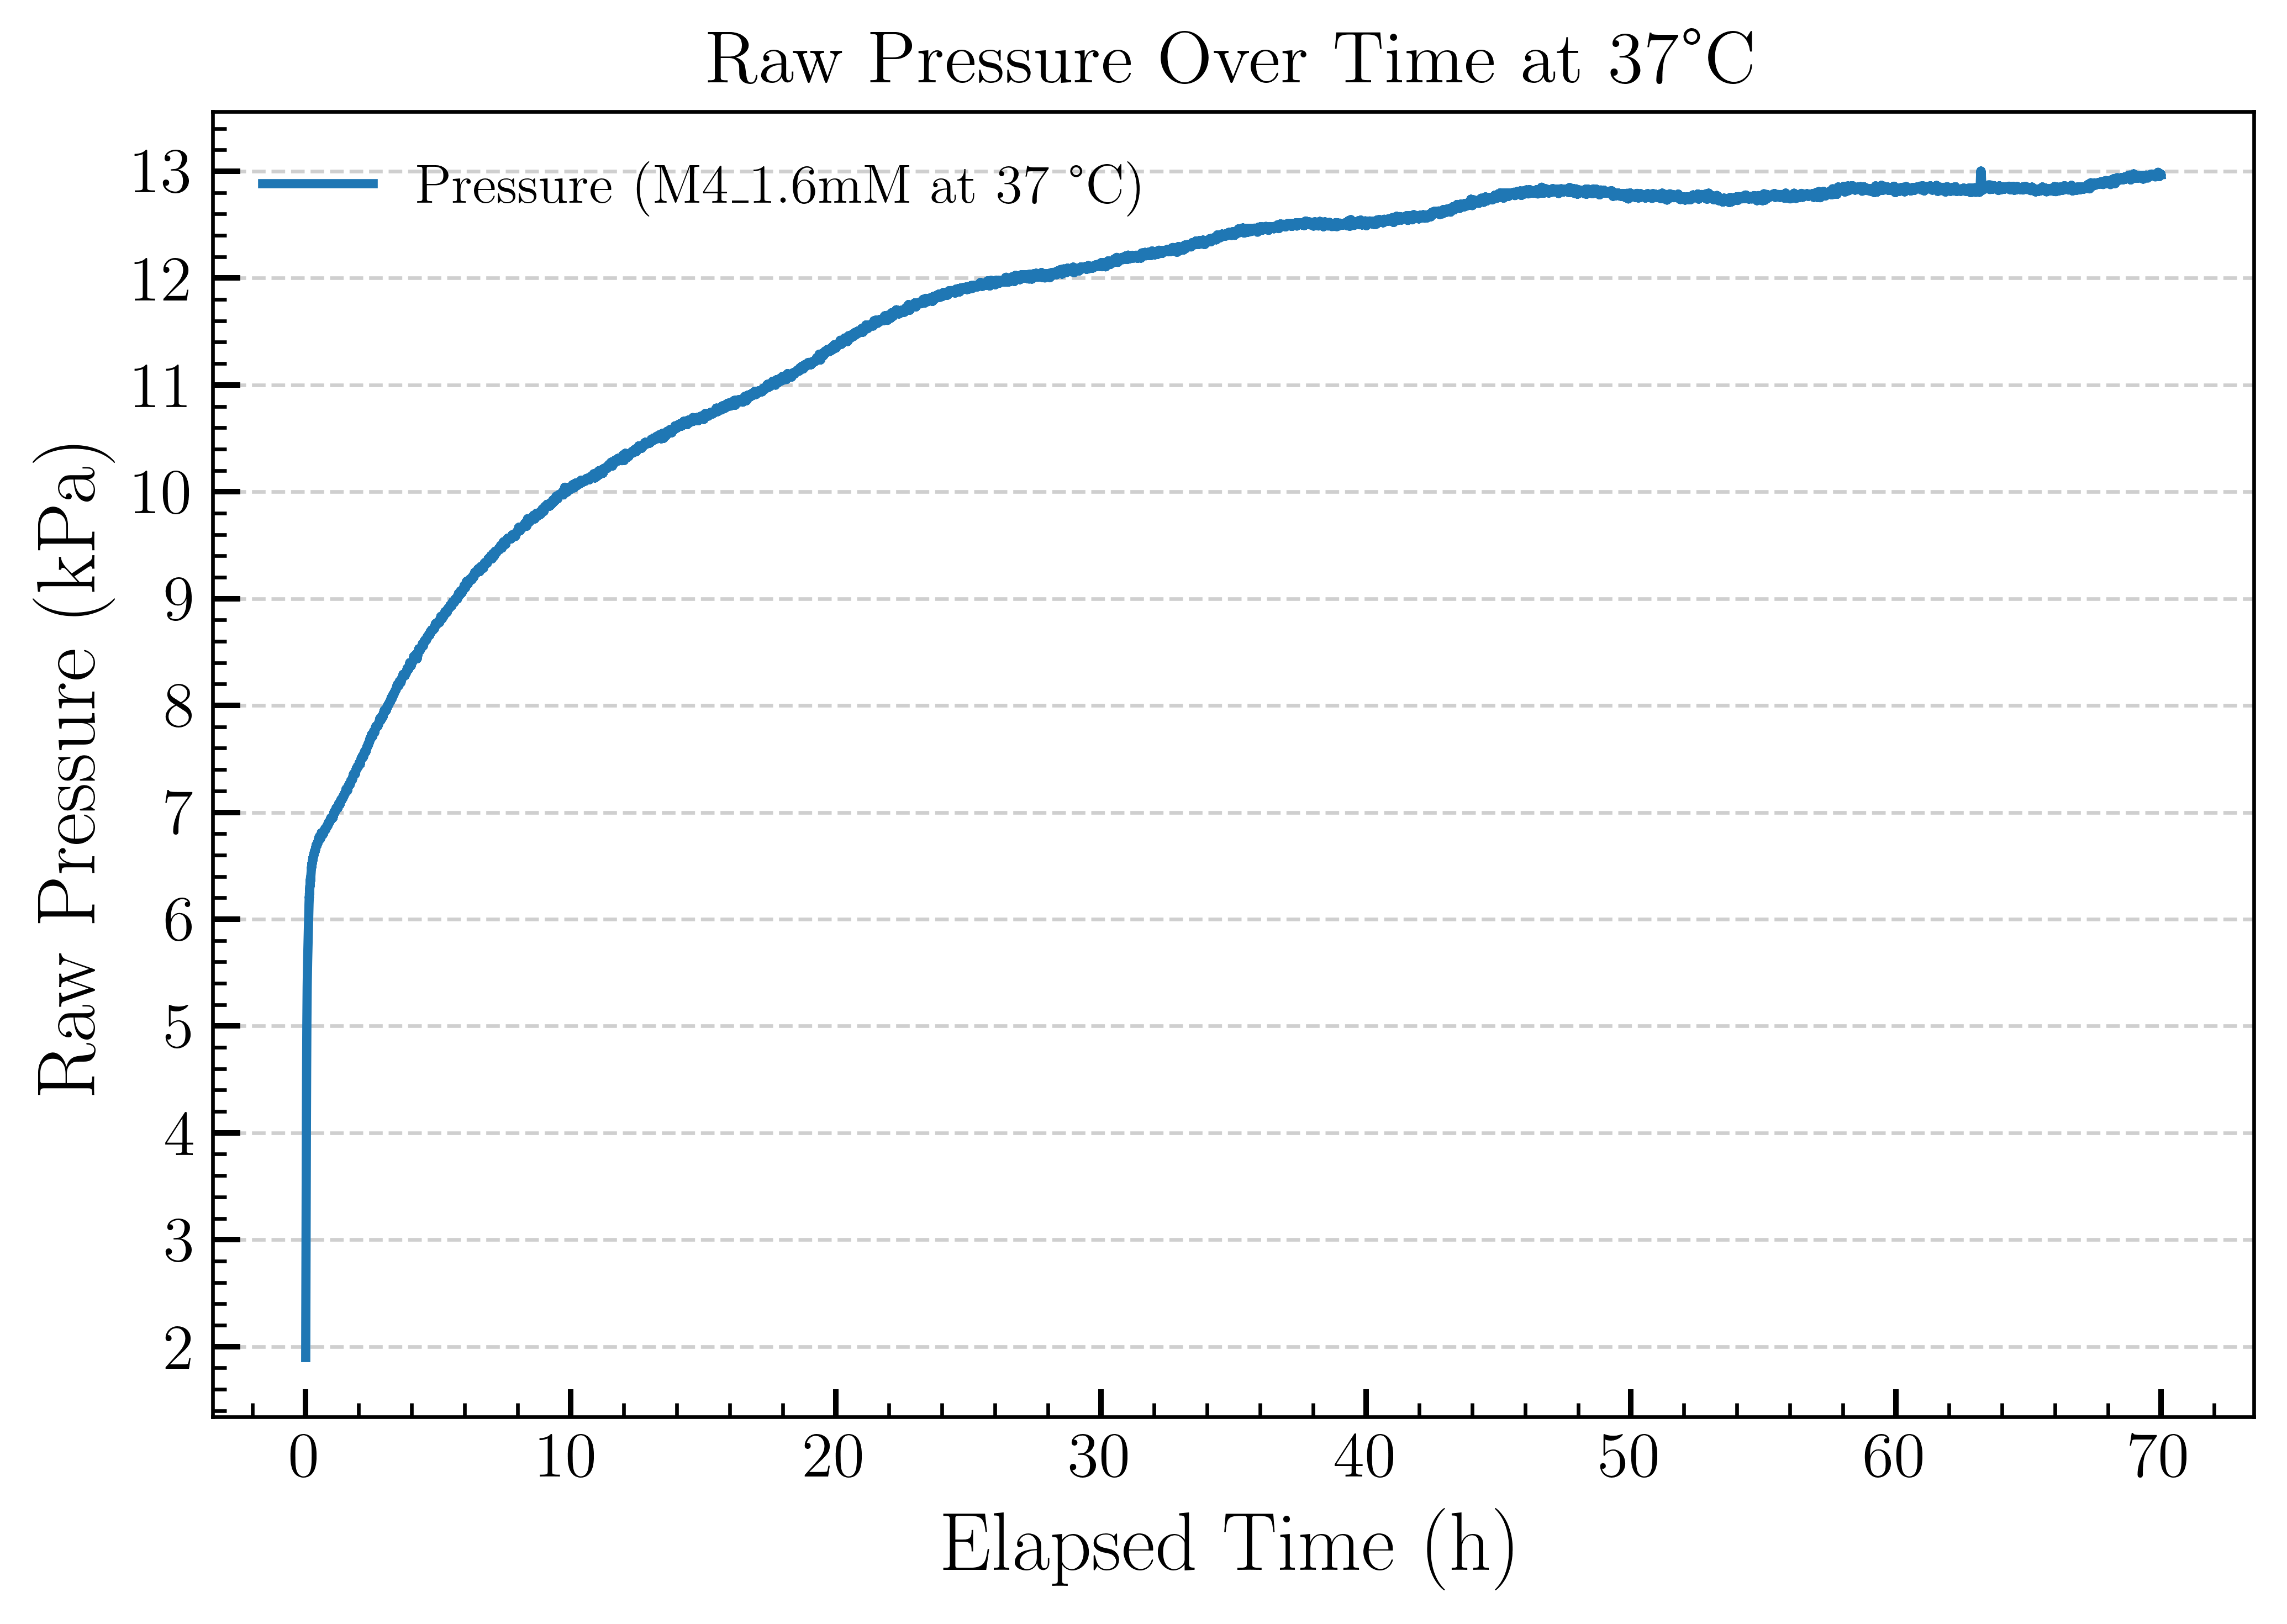

In [2]:
path = r"C:\Users\chand\Documents\GitHub\Thesis\M4-1.6 mM\37 C\raw dataset\concatinated\merged_pressure_log.csv"
df_1 = pd.read_csv(path)

count = (df_1["ABP2-Sch1 (kPa)"] == -2).sum()
print("count of -2 in there is: ", count)

df_1 = df_1[df_1["Elapsed Time (hours)"] <= 70].reset_index(drop=True)



fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_1["Elapsed Time (hours)"],
         df_1["ABP2-Sch1 (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M4_1.6mM at 37 °C)')

ax1.set_title('Raw Pressure Over Time at 37°C', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.savefig('M4_1.6mM_37C_raw_pressure.png', dpi=dpi, bbox_inches='tight')
plt.show()

# Zoomed in view

# First 5 h

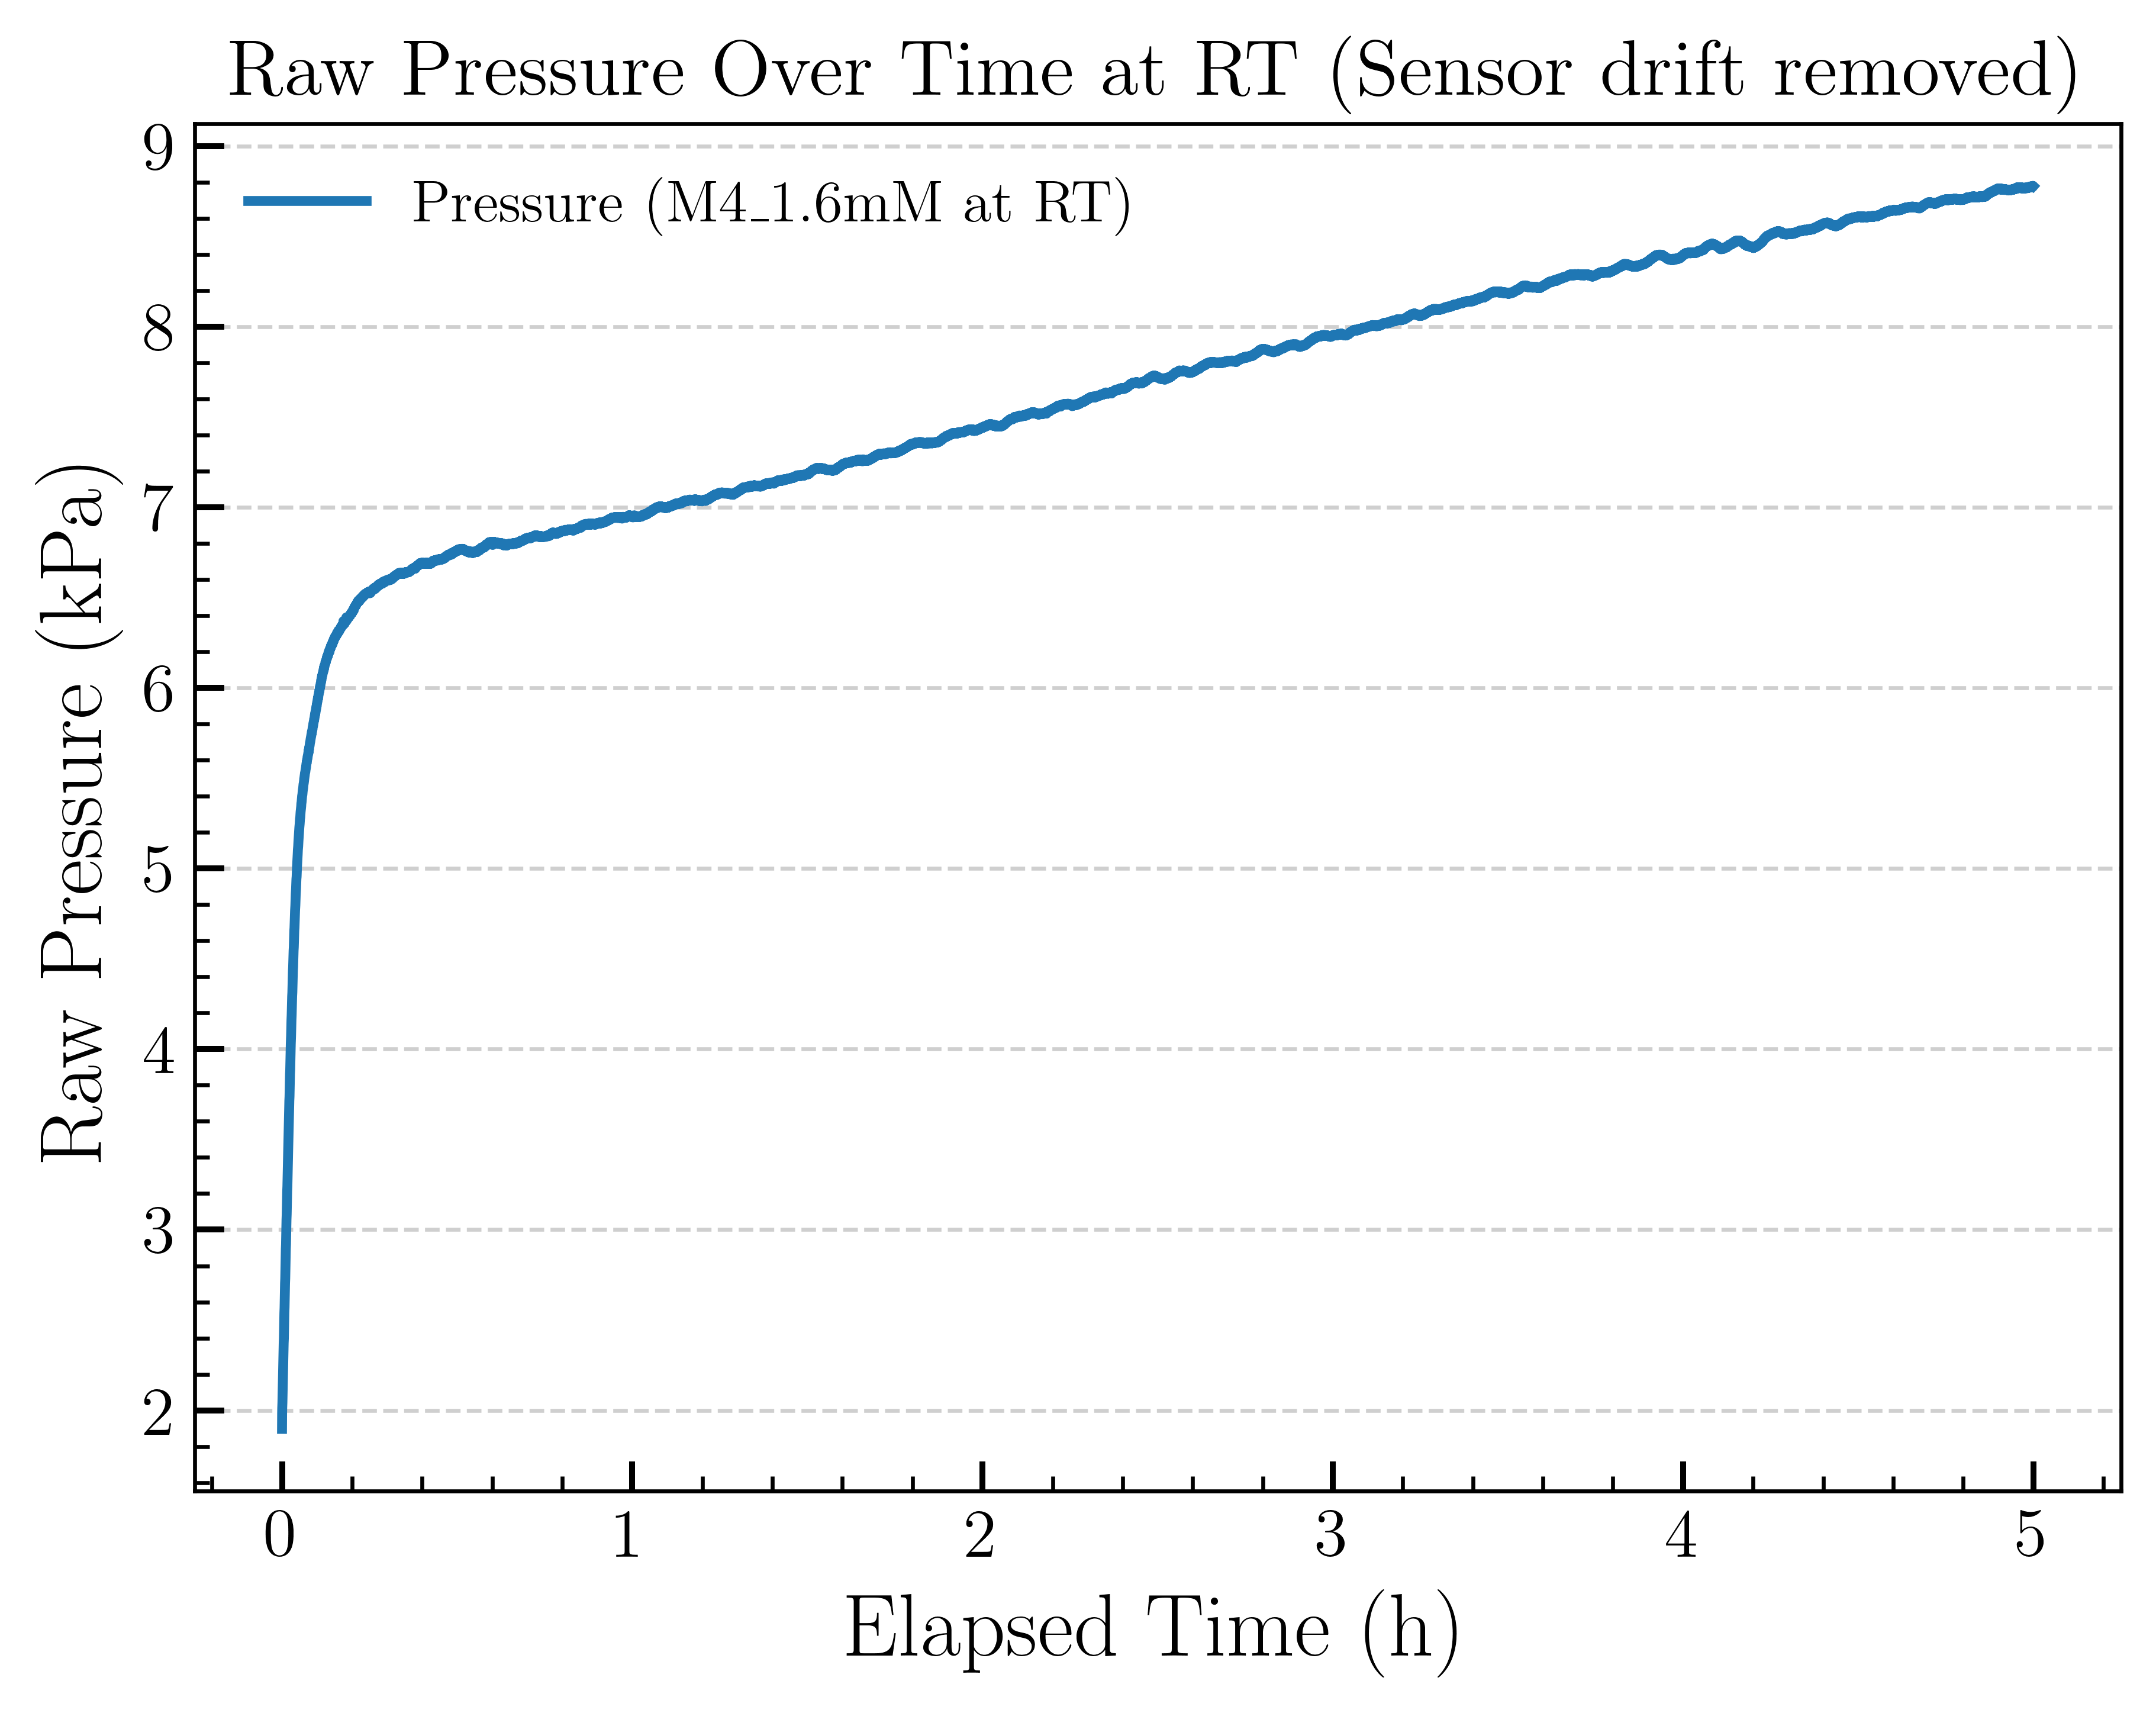

In [ ]:


#Plotting the data only from 0 to 5 h
df_sensor = df_1[df_1["Elapsed Time (hours)"] <= 5]


fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_sensor["Elapsed Time (hours)"],
         df_sensor["ABP2-Sch1 (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M4_1.6mM at RT)')

ax1.set_title('Raw Pressure Over Time at RT (Sensor drift removed)', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")

plt.show()

# First 10 minutes

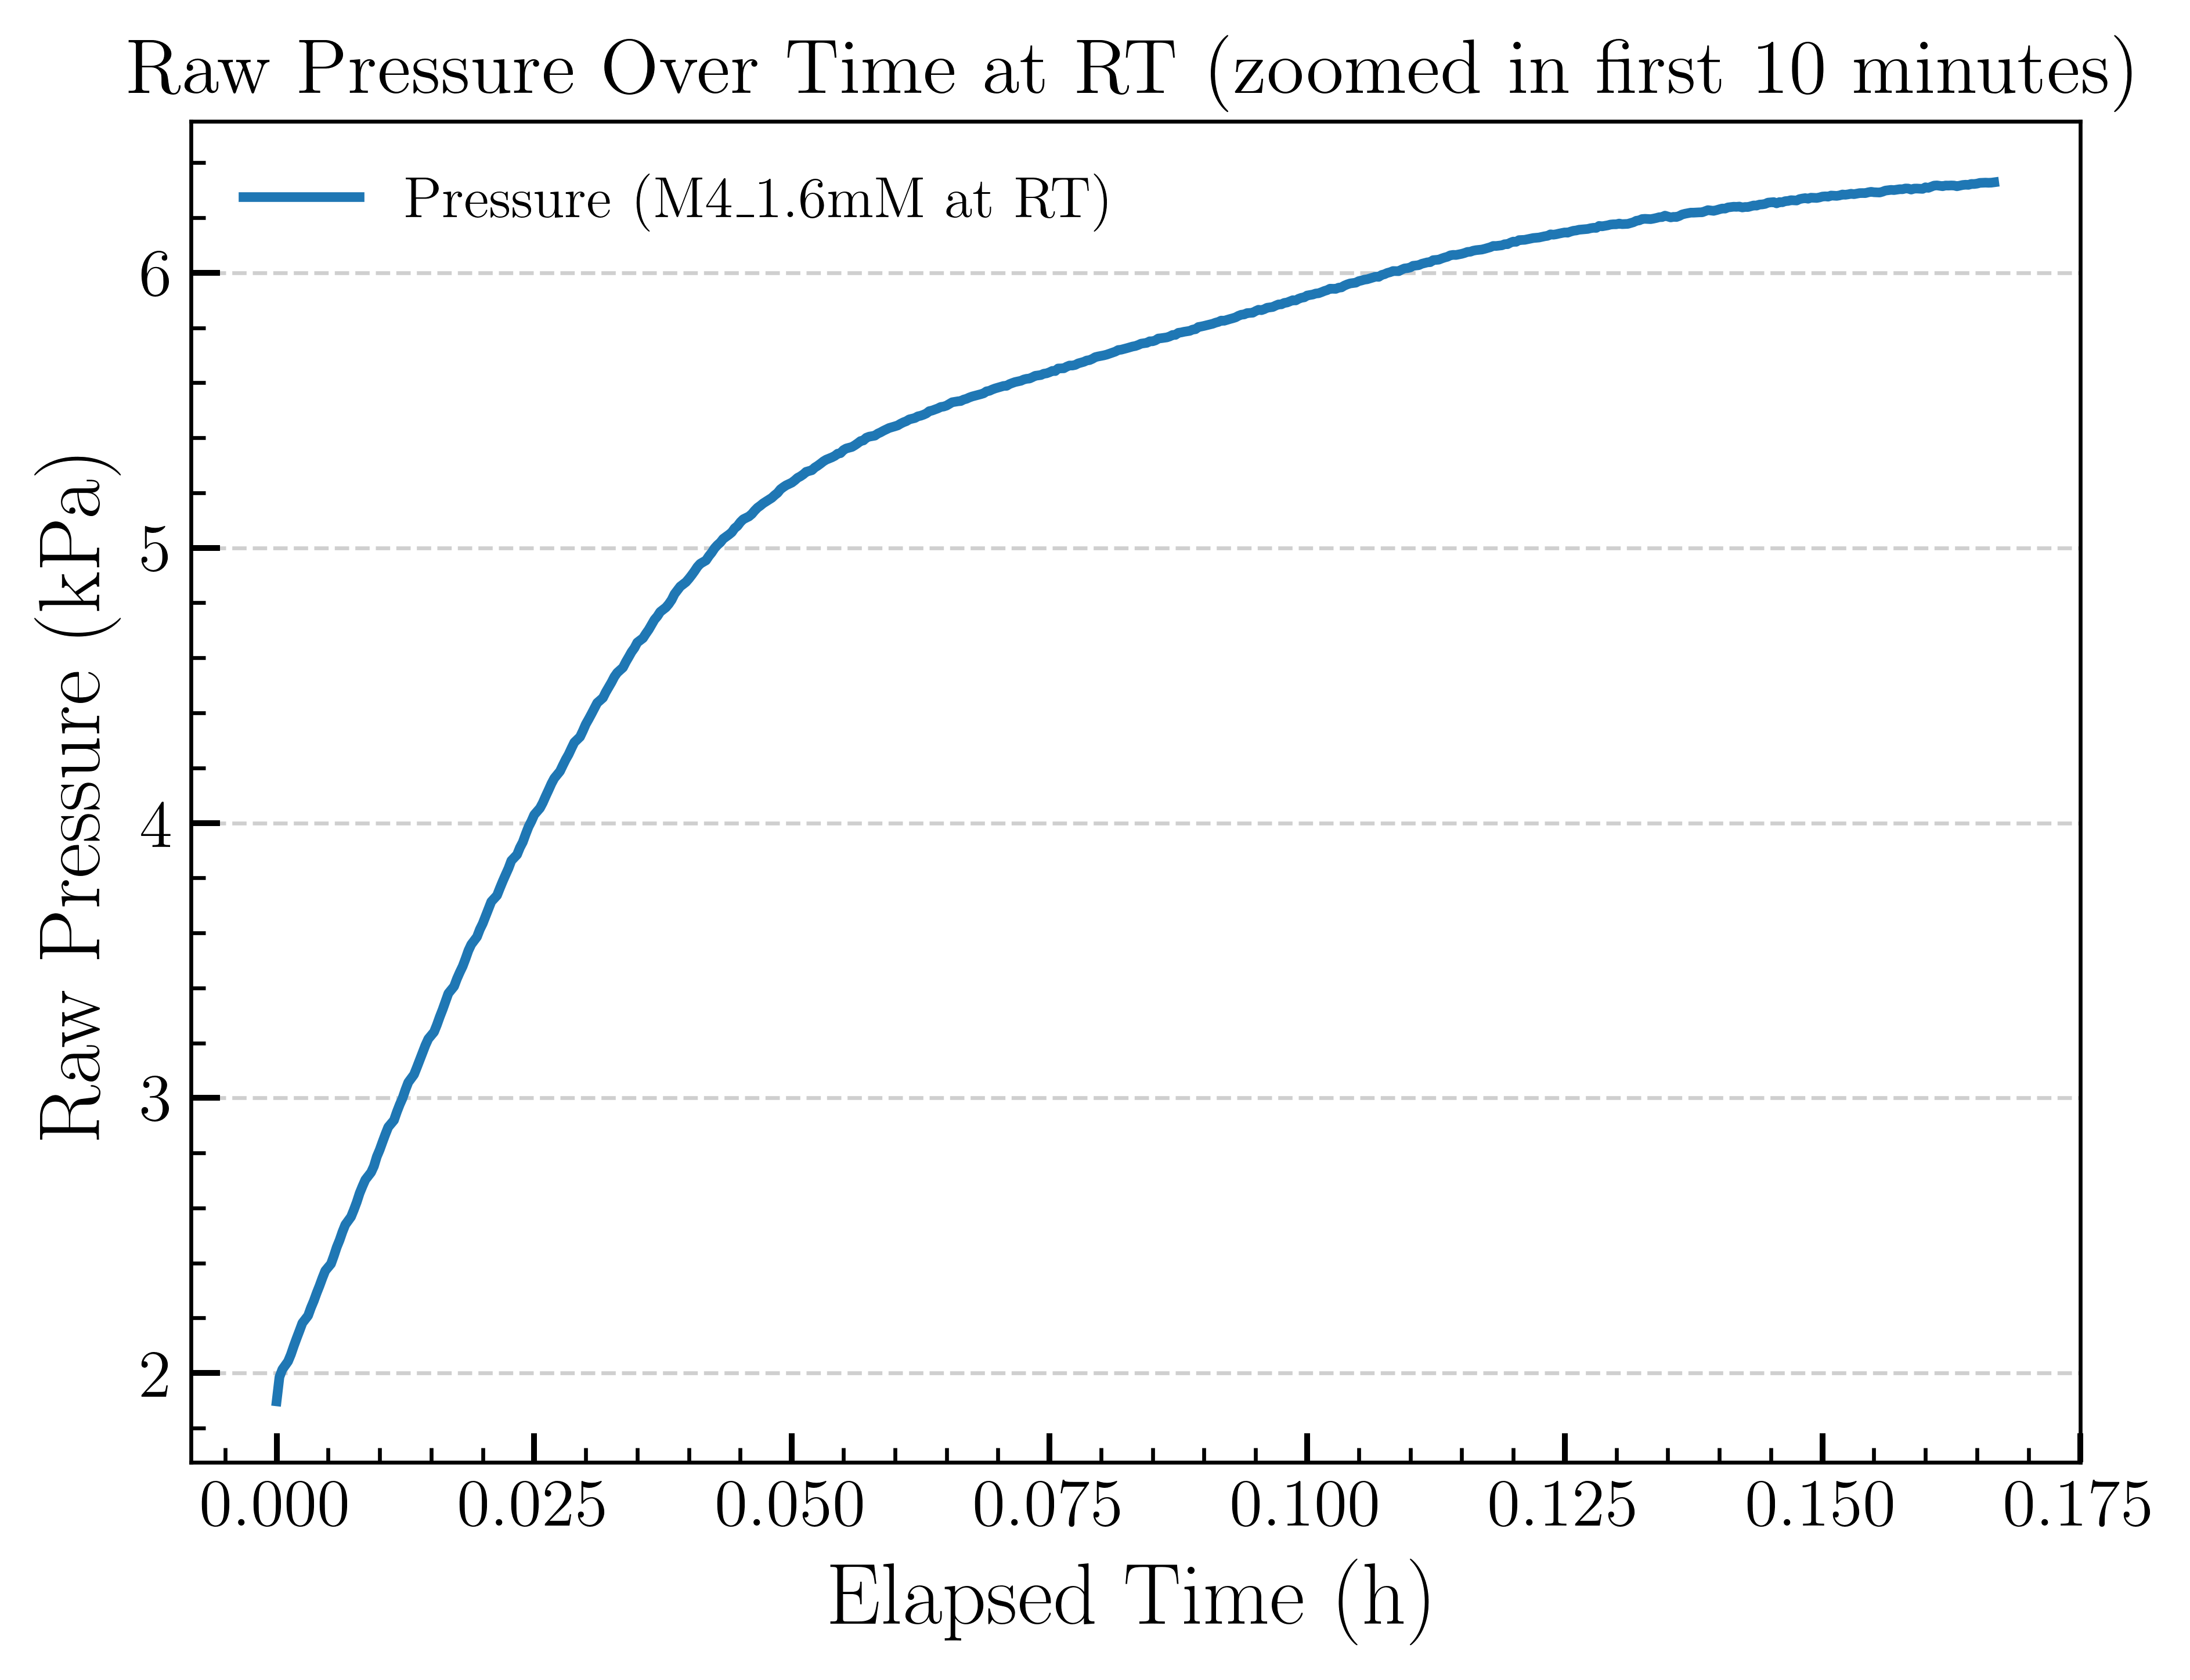

In [6]:


#Plotting the data only from 0 to 10 minutes
df_sensor = df_1[df_1["Elapsed Time (hours)"] <= 0.1667]


fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_sensor["Elapsed Time (hours)"],
         df_sensor["ABP2-Sch1 (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M4_1.6mM at RT)')

ax1.set_title('Raw Pressure Over Time at RT (zoomed in first 10 minutes)', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")

plt.show()

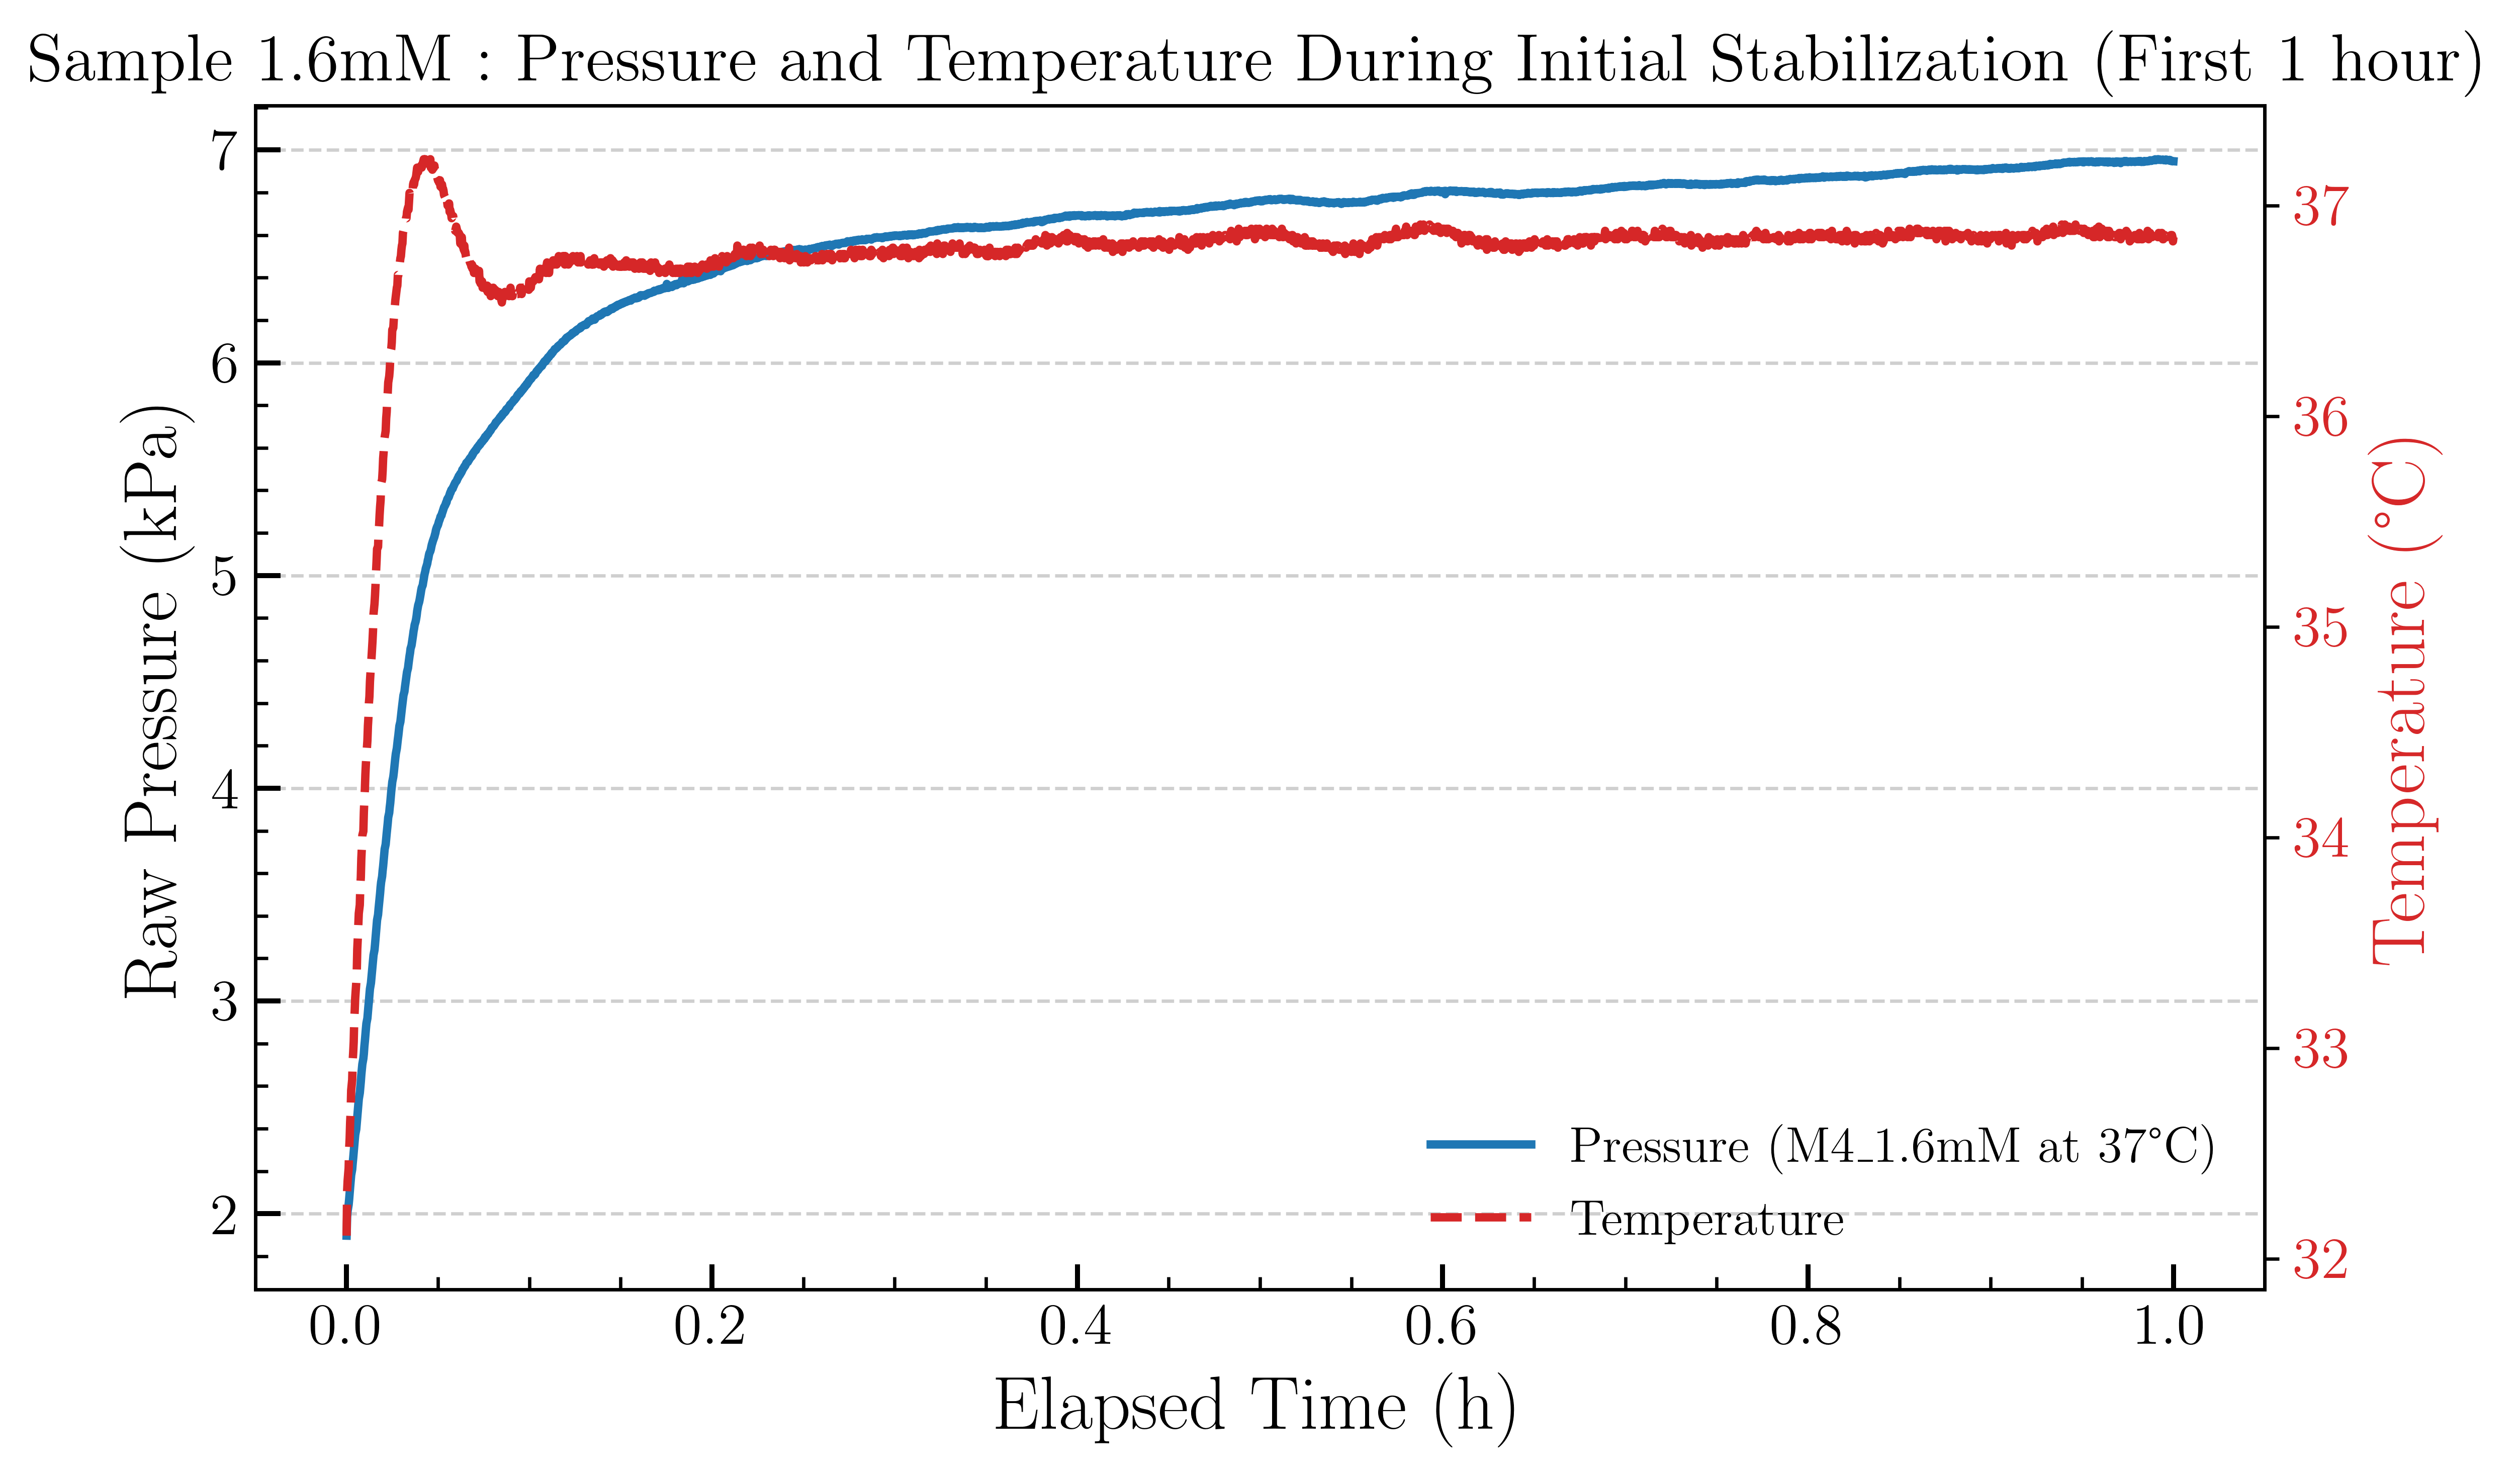

In [61]:
df_sensor = df_1[df_1["Elapsed Time (hours)"] <= 1]

# To show temperature dependence, plot both pressure and temperature
fig, ax1 = plt.subplots(figsize=(8,5), dpi=dpi)

# Plot pressure on primary y-axis
ax1.plot(df_sensor["Elapsed Time (hours)"],
         df_sensor["ABP2-Sch1 (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M4_1.6mM at 37°C)')

# Create secondary y-axis for temperature
ax2 = ax1.twinx()
ax2.plot(df_sensor["Elapsed Time (hours)"],
         df_sensor["Temperature (C)"],
         lw=2.0, color="tab:red", linestyle='--',
         label=r'Temperature')

ax1.set_title('Sample 1.6mM : Pressure and Temperature During Initial Stabilization (First 1 hour)', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax2.set_ylabel("Temperature (°C)", fontsize=18, color="tab:red")
ax2.tick_params(axis='y', labelcolor="tab:red", labelsize=14)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, fontsize=12, loc="best")

plt.tight_layout()
plt.show()

# Denoising is done on the code M4_1.6_37deg_plots_P_T_SG_DWT.py

# MPR raw graph

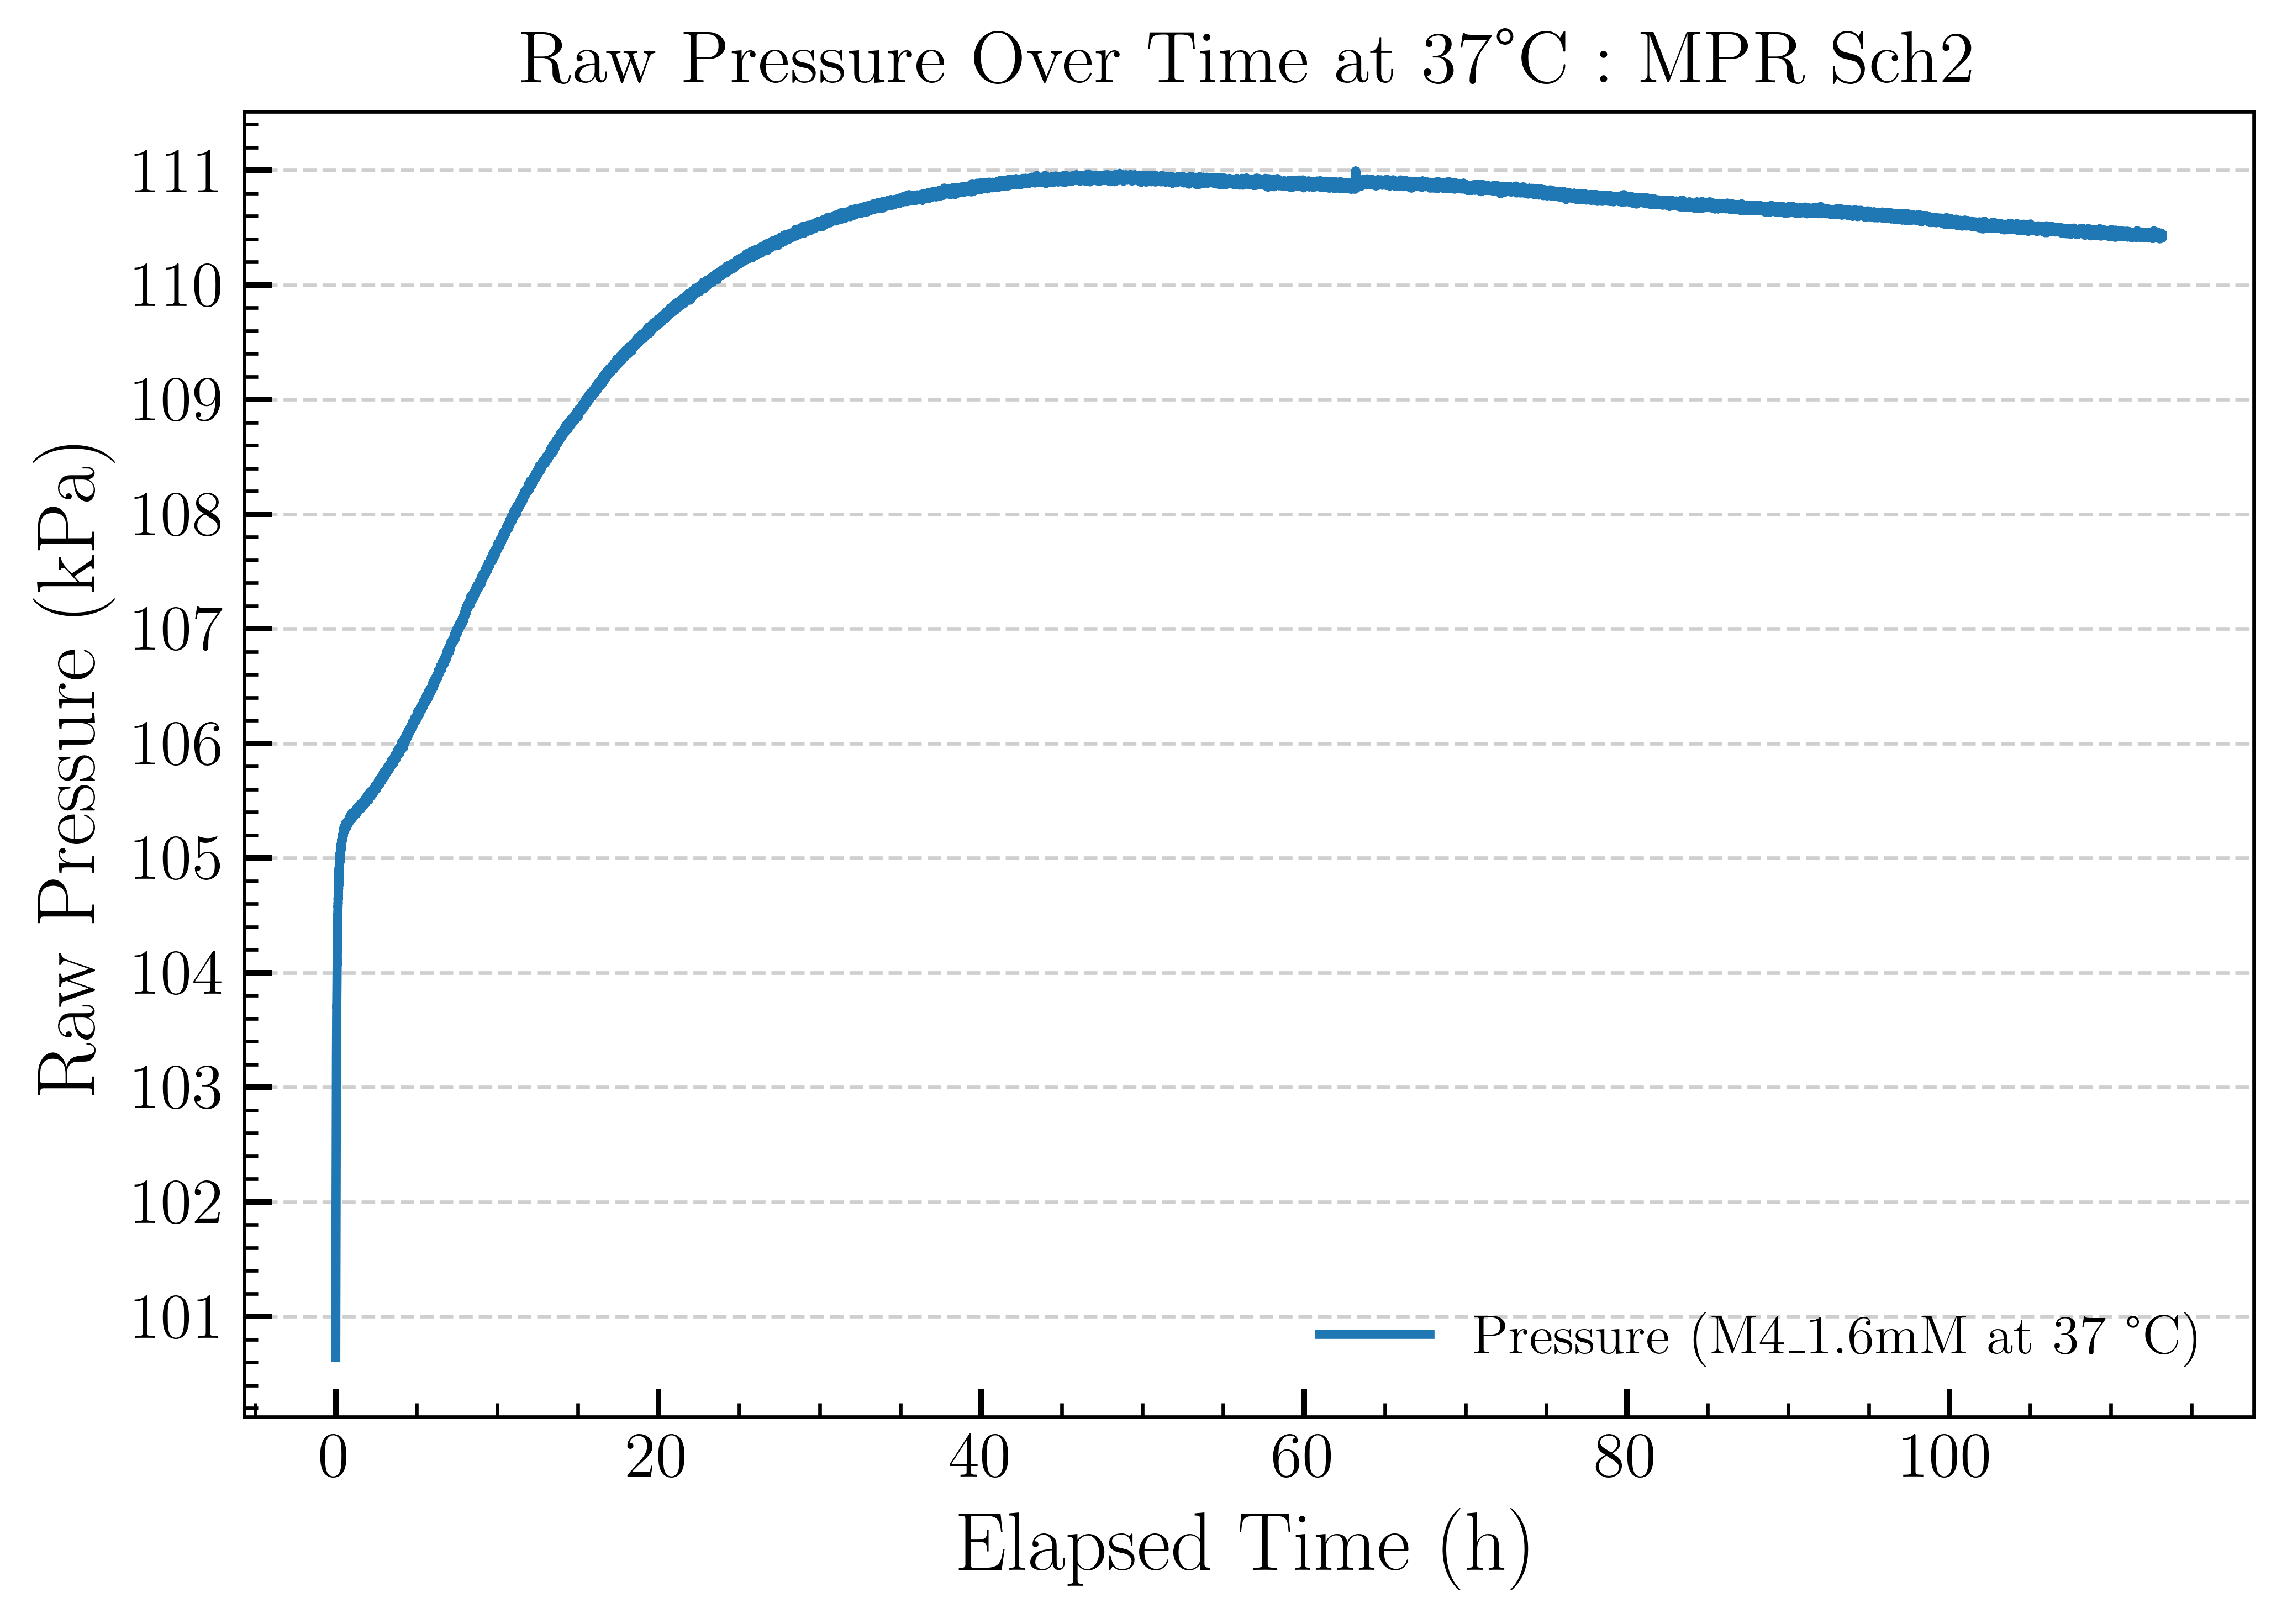

In [15]:
path_1 = r"C:\Users\chand\Documents\GitHub\Thesis\M4-1.6 mM\37 C\raw dataset\concatinated\merged_pressure_log.csv"
df_2 = pd.read_csv(path_1)



df_1 = df_2[df_2["Elapsed Time (hours)"] <= 70].reset_index(drop=True)



fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_2["Elapsed Time (hours)"],
         df_2["MPR-Sch2 (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M4_1.6mM at 37 °C)')

ax1.set_title('Raw Pressure Over Time at 37°C : MPR Sch2', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()

plt.show()

# Ngas on ABp2 and MPR

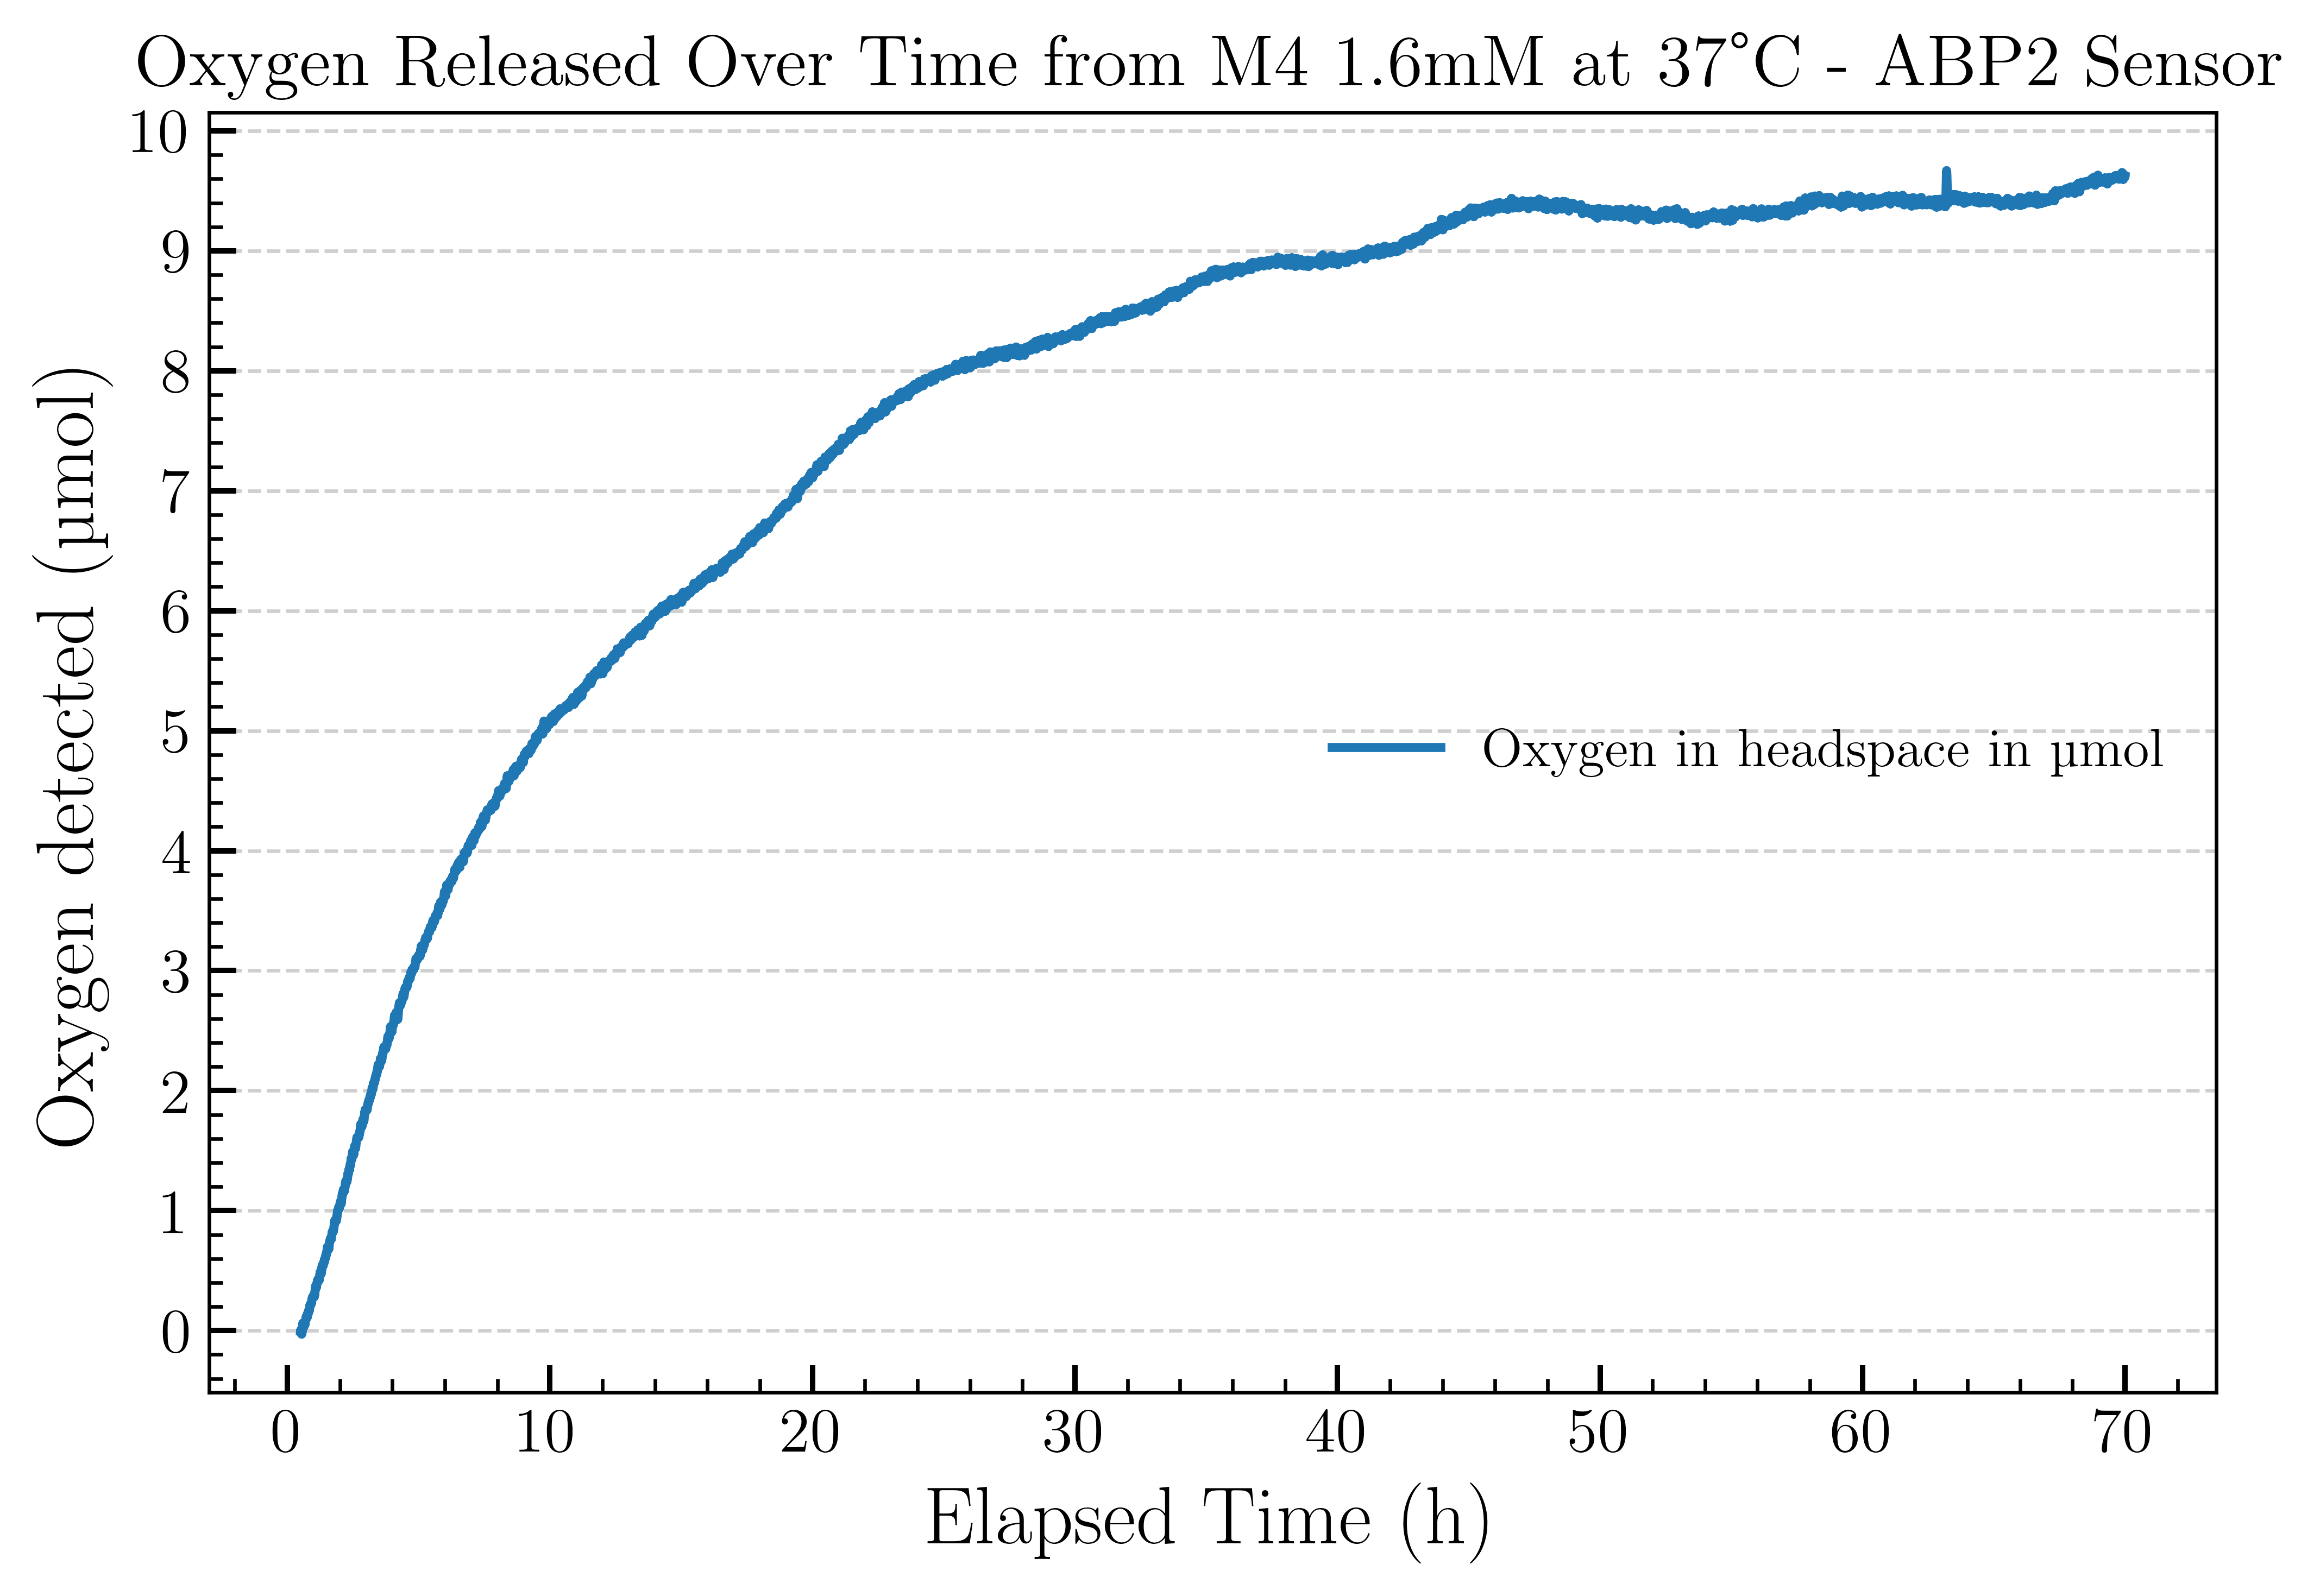

In [69]:
main = r"C:\Users\chand\Documents\GitHub\Thesis\M4-1.6 mM\37 C\code files\M4_1.6mM_37deg_pressure_o2_release.csv"

df_main = pd.read_csv(main)
df_main.columns = [c.strip() for c in df_main.columns]
df_main = df_main[df_main["Time (h)"] <= 70].reset_index(drop=True)


headspace_oxygen = df_main["ABP2 O2 Released (µmol)"]
time_col = df_main["Time (h)"]

# df_sensor = df[df["Elapsed Time (hours)"] > 0.5]



fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(time_col,
         headspace_oxygen,
         lw=2.0, color="tab:blue",
         label=r'Oxygen in headspace in µmol')
        
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Oxygen detected (µmol)", y_major=1.0)
ax1.set_title('Oxygen Released Over Time from M4 1.6mM at 37°C - ABP2 Sensor', fontsize=16)
ax1.legend(frameon=False, fontsize=12, loc="right")
plt.tight_layout()

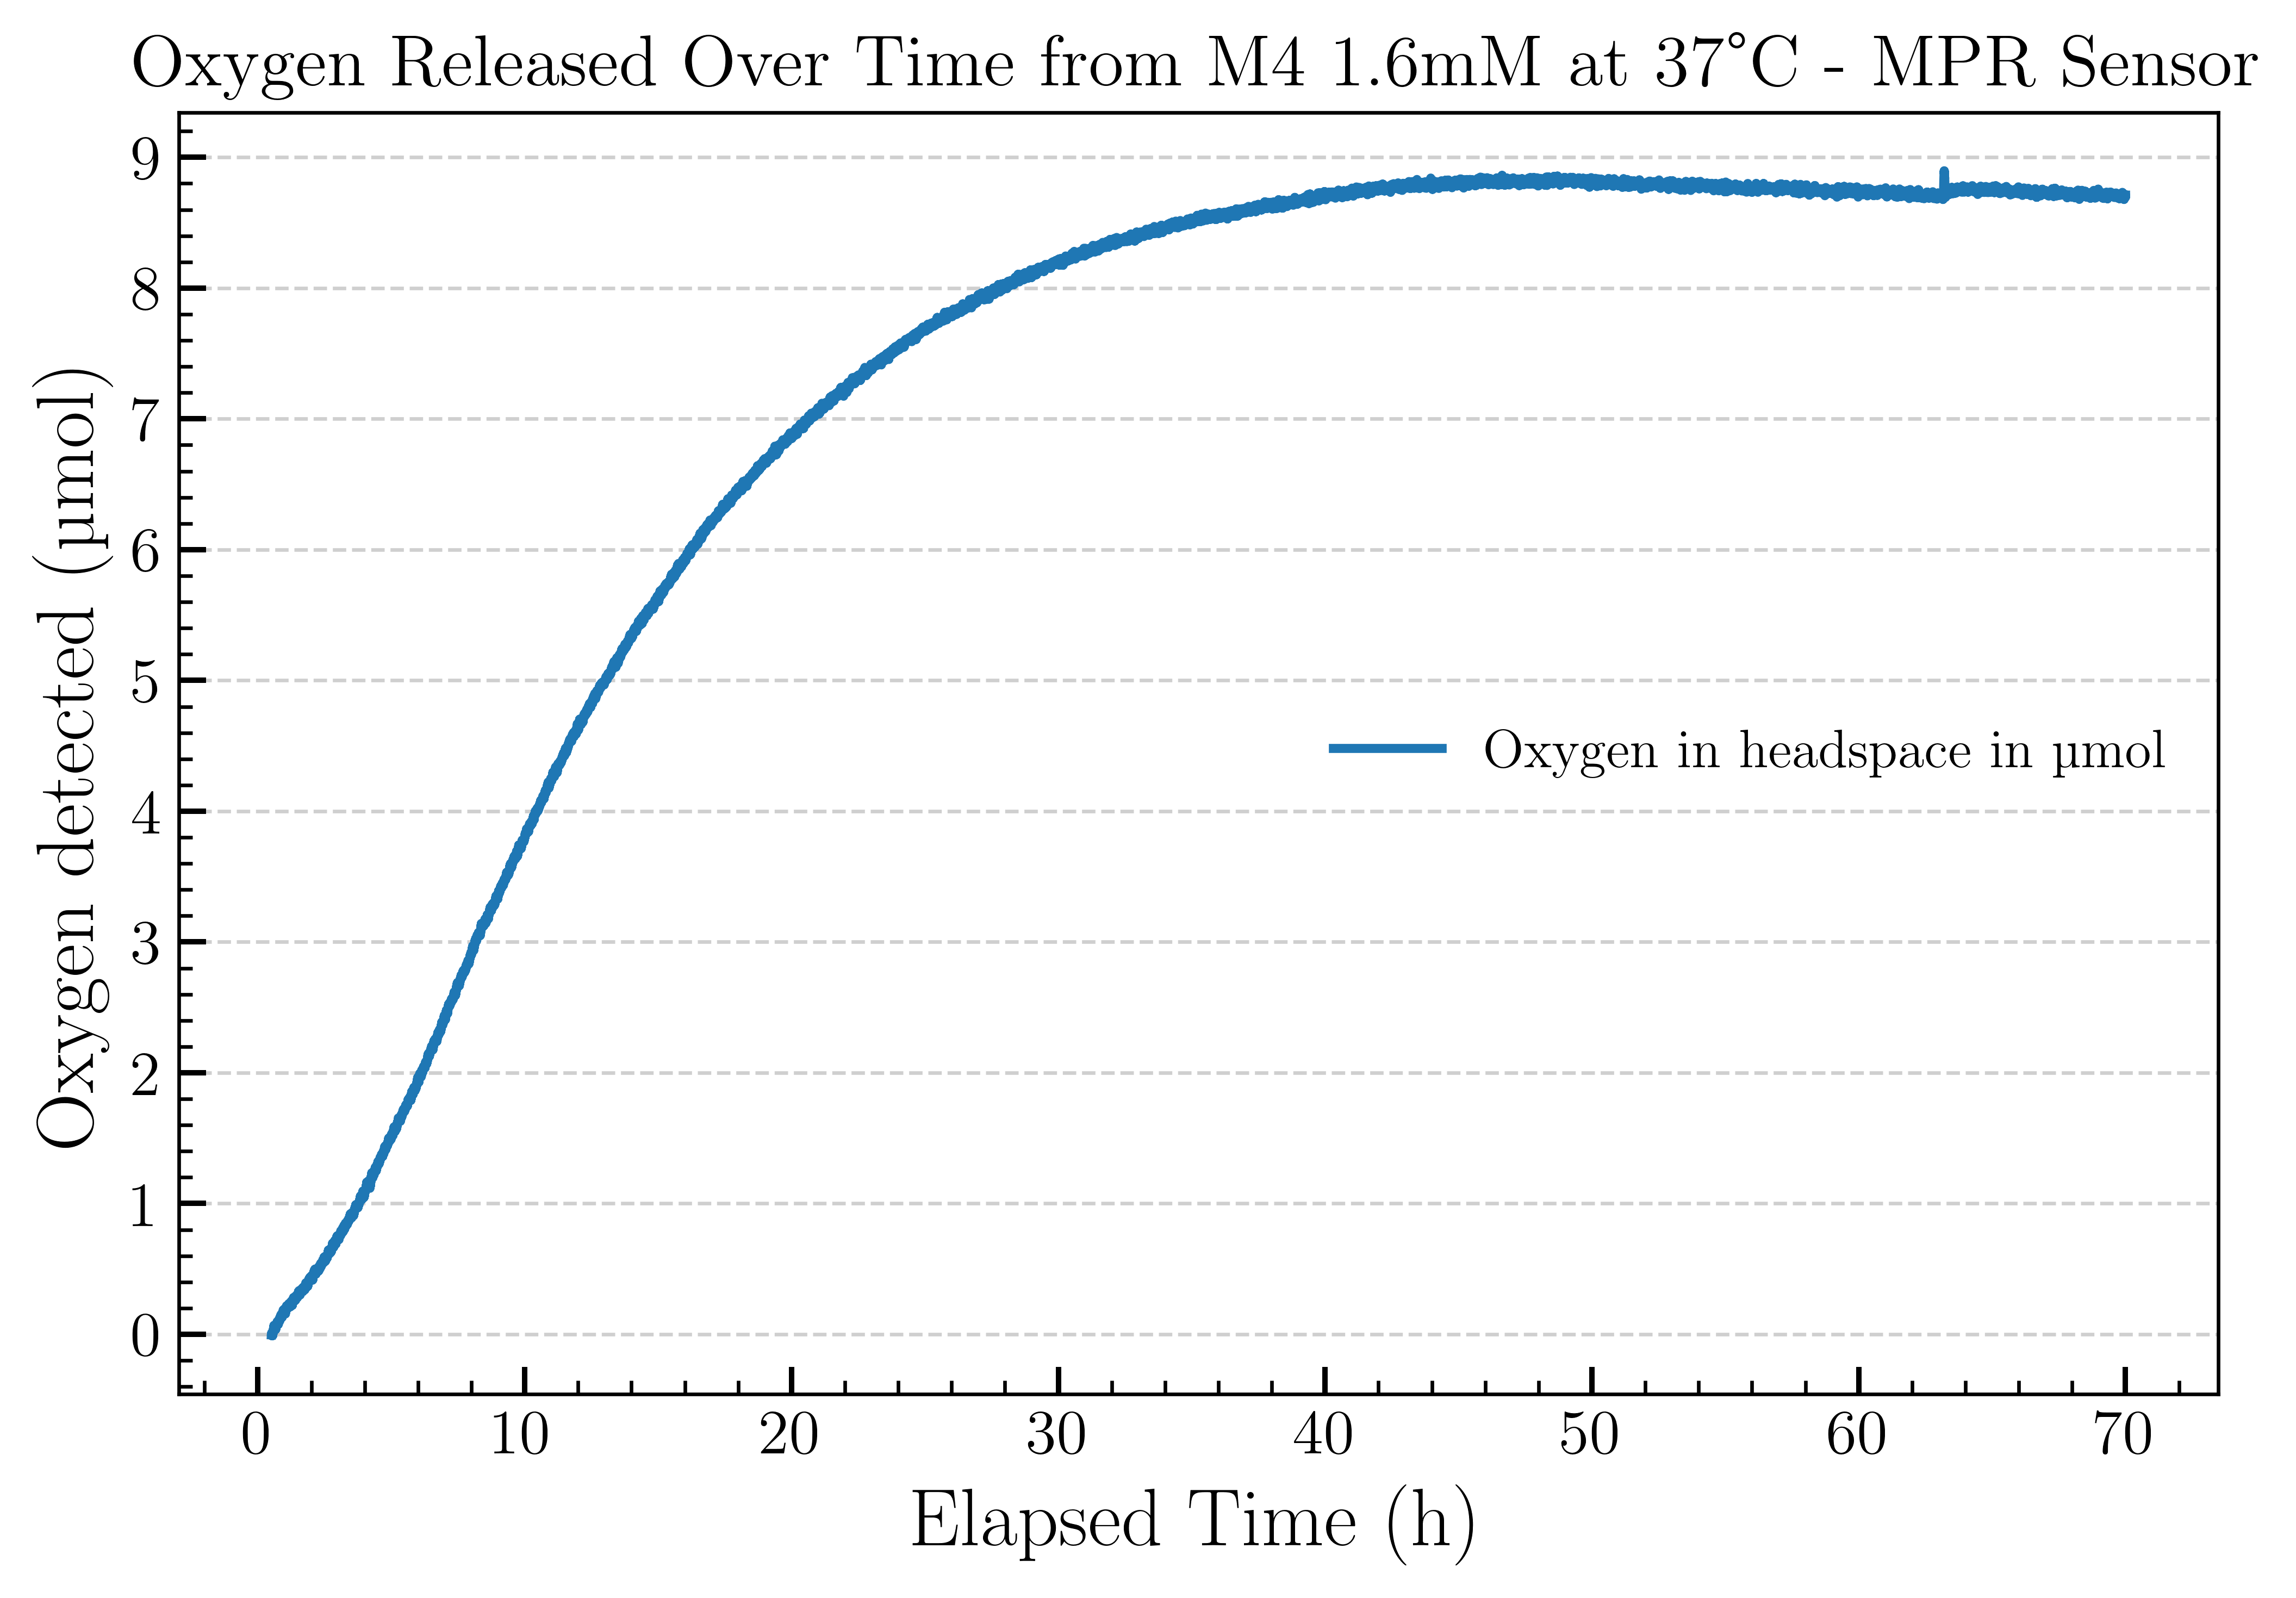

In [67]:
main = r"C:\Users\chand\Documents\GitHub\Thesis\M4-1.6 mM\37 C\code files\M4_1.6mM_37deg_pressure_o2_release.csv"

df_main = pd.read_csv(main)
df_main.columns = [c.strip() for c in df_main.columns]
df_main = df_main[df_main["Time (h)"] <= 70].reset_index(drop=True)


headspace_oxygen = df_main["MPR O2 Released (µmol)"]
time_col = df_main["Time (h)"]

# df_sensor = df[df["Elapsed Time (hours)"] > 0.5]



fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(time_col,
         headspace_oxygen,
         lw=2.0, color="tab:blue",
         label=r'Oxygen in headspace in µmol ')
        
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Oxygen detected (µmol)", y_major=1.0)
ax1.set_title('Oxygen Released Over Time from M4 1.6mM at 37°C - MPR Sensor', fontsize=16)
ax1.legend(frameon=False, fontsize=12, loc="right")
plt.tight_layout()

# Plotting concentration decay

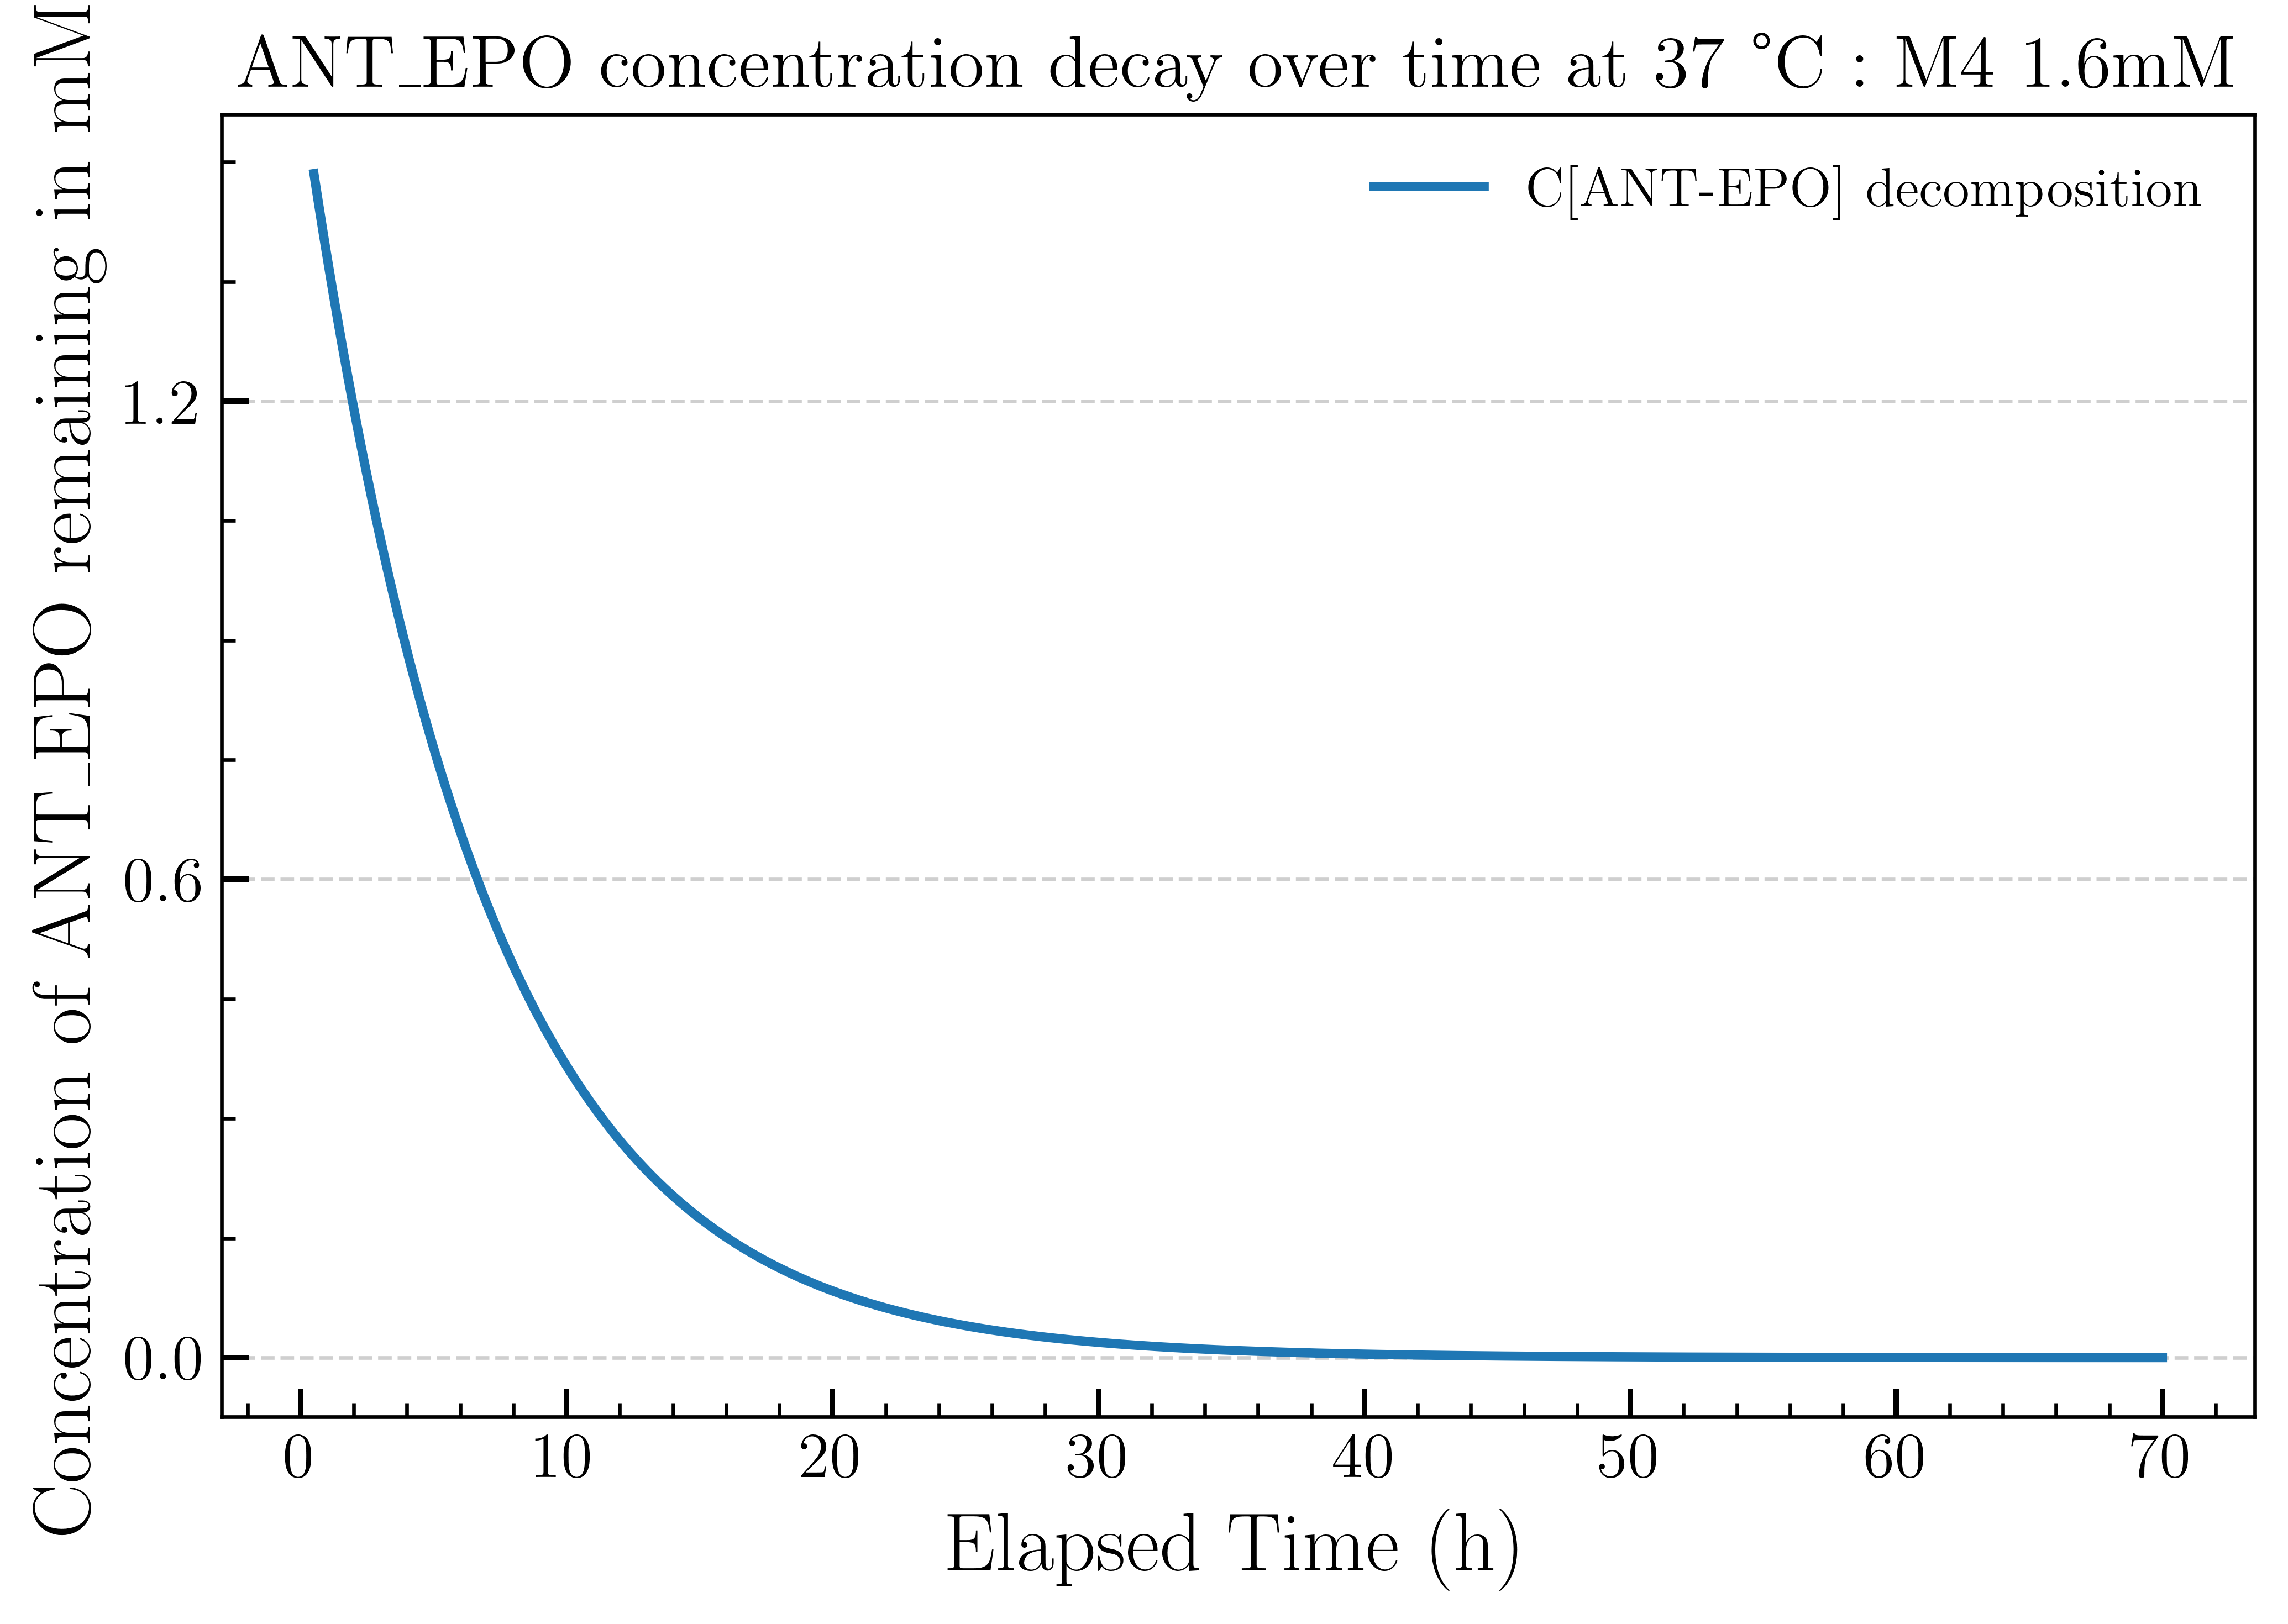

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Aim is to find N(t) = N0 * 0.5^(t/t_half)  #First order kinetic decay

n_0 = 1.6  # initial ANT- EPO concentration in mM
t_halflife = 4.7 #hours at 37



csv_path = r"C:\Users\chand\Documents\GitHub\Thesis\M4-1.6 mM\37 C\code files\M4_1.6mM_37deg_pressure_o2_release.csv"
# csv_path = r"C:\Users\chand\Documents\GitHub\Thesis\M4-1.6 mM\37 C\raw dataset\concatinated\merged_pressure_log.csv"
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

df["Elapsed time"] = pd.to_numeric(df["Time (h)"])   

# df["Elapsed time"] = pd.to_numeric(df["Elapsed Time (hours)"])   

df["N (t)"] = n_0 * 0.5**(df["Elapsed time"] / t_halflife)  #N(t) is also in mM   #Modelling the remaining amount of reactant ANT-EPO that decomposes gradually ad the reaction proceeds

df["N (t) in %"] = (df["N (t)"] / n_0) * 100  #N(t) in percentage

df["C_ANT_mM"] = n_0 - df["N (t)"] 


out_dataframe = df[["Elapsed time", "N (t)", "N (t) in %", "C_ANT_mM"]]







fig, ax1 = plt.subplots(figsize=(7,5), dpi=600)
ax1.plot(out_dataframe["Elapsed time"], out_dataframe["N (t)"], linewidth =2,
         label=r'C[ANT-EPO] decomposition')

ax1.set_title('ANT_EPO concentration decay over time at 37 °C : M4 1.6mM', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Concentration of ANT_EPO remaining in mM", y_major=0.6)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()

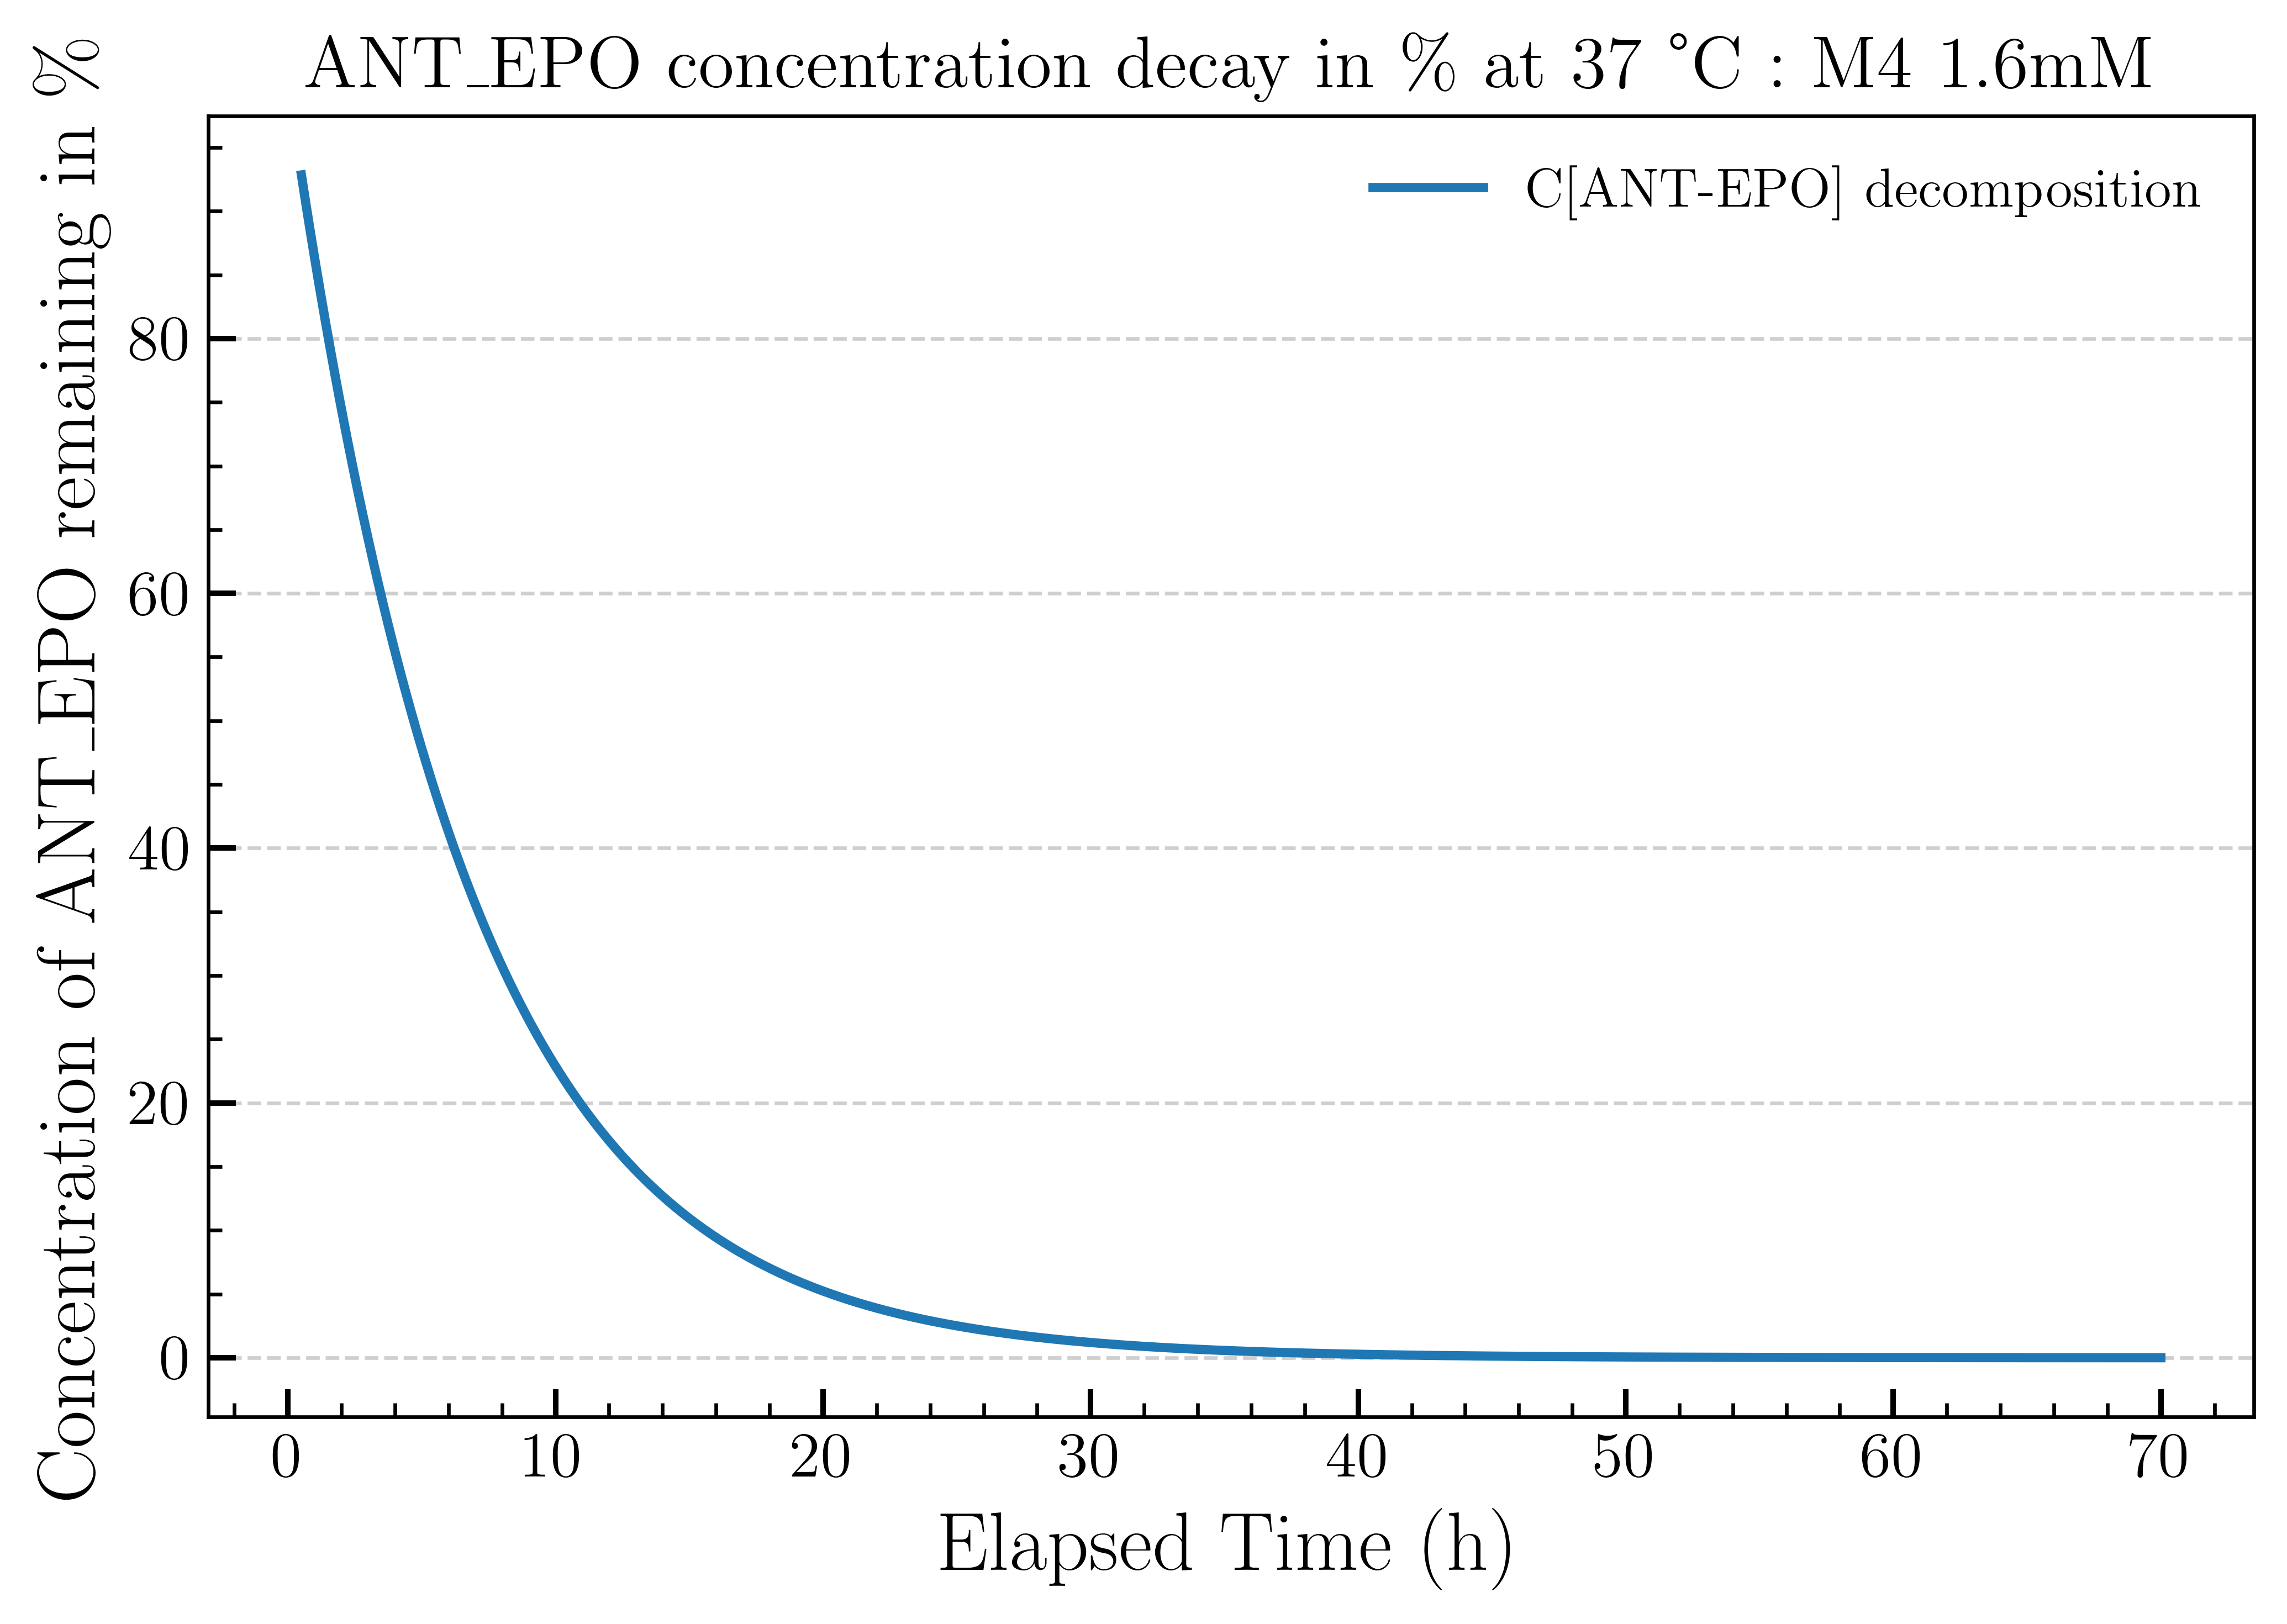

In [59]:




fig, ax1 = plt.subplots(figsize=(7,5), dpi=600)
ax1.plot(out_dataframe["Elapsed time"], out_dataframe["N (t) in %"], linewidth =2,
         label=r'C[ANT-EPO] decomposition')

ax1.set_title('ANT_EPO concentration decay in \\%  at 37 °C : M4 1.6mM', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Concentration of ANT_EPO remaining in \\%", y_major=20.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd
import numpy as np

# Parameters
n_0 = 1.6       # initial ANT-EPO concentration in mM
t_halflife = 4.7 # hours at 37

# Table 9 timestamps (in hours)
timestamps_h = [0, 0.46, 1.005, 2.238, 3.405, 5.388, 6.172, 7.222, 
                22.85, 47.27, 71.38, 100]

# Convert into DataFrame
df_out = pd.DataFrame({"Elapsed_h": timestamps_h})
# Compute N(t), % remaining, and ANT formed
df_out["C_EPO_mM"] = n_0 * 0.5**(df_out["Elapsed_h"] / t_halflife)  # remaining ANT-EPO
df_out["EPO_remaining_%"] = (df_out["C_EPO_mM"] / n_0) * 100        # %
df_out["C_ANT_mM"] = n_0 - df_out["C_EPO_mM"]                       # formed anthracene


# Save or display
print(df_out.head())
df_out.to_csv("CANT_release_table.csv", index=False)

   Elapsed_h  C_EPO_mM  EPO_remaining_%  C_ANT_mM
0      0.000  1.600000       100.000000  0.000000
1      0.460  1.495056        93.441003  0.104944
2      1.005  1.379592        86.224527  0.220408
3      2.238  1.150214        71.888345  0.449786
4      3.405  0.968352        60.522015  0.631648


In [20]:
from tabulate import tabulate

# Round values for readability
df_out_rounded = df_out.round({

    "C_EPO_mM": 3,
    "EPO_remaining_%": 2,
    "C_ANT_mM": 3
})

# Create a clean table string
table_str = tabulate(
    df_out_rounded,
    headers=[ "C_EPO (mM)", "EPO Remaining (%)", "C_ANT (mM)"],
    tablefmt="github"
)

print(table_str)

|    |         |   C_EPO (mM) |   EPO Remaining (%) |   C_ANT (mM) |
|----|---------|--------------|---------------------|--------------|
|  0 |   0     |        1.6   |              100    |        0     |
|  1 |   0.46  |        1.495 |               93.44 |        0.105 |
|  2 |   1.005 |        1.38  |               86.22 |        0.22  |
|  3 |   2.238 |        1.15  |               71.89 |        0.45  |
|  4 |   3.405 |        0.968 |               60.52 |        0.632 |
|  5 |   5.388 |        0.723 |               45.18 |        0.877 |
|  6 |   6.172 |        0.644 |               40.24 |        0.956 |
|  7 |   7.222 |        0.552 |               34.47 |        1.048 |
|  8 |  22.85  |        0.055 |                3.44 |        1.545 |
|  9 |  47.27  |        0.002 |                0.09 |        1.598 |
| 10 |  71.38  |        0     |                0    |        1.6   |
| 11 | 100     |        0     |                0    |        1.6   |


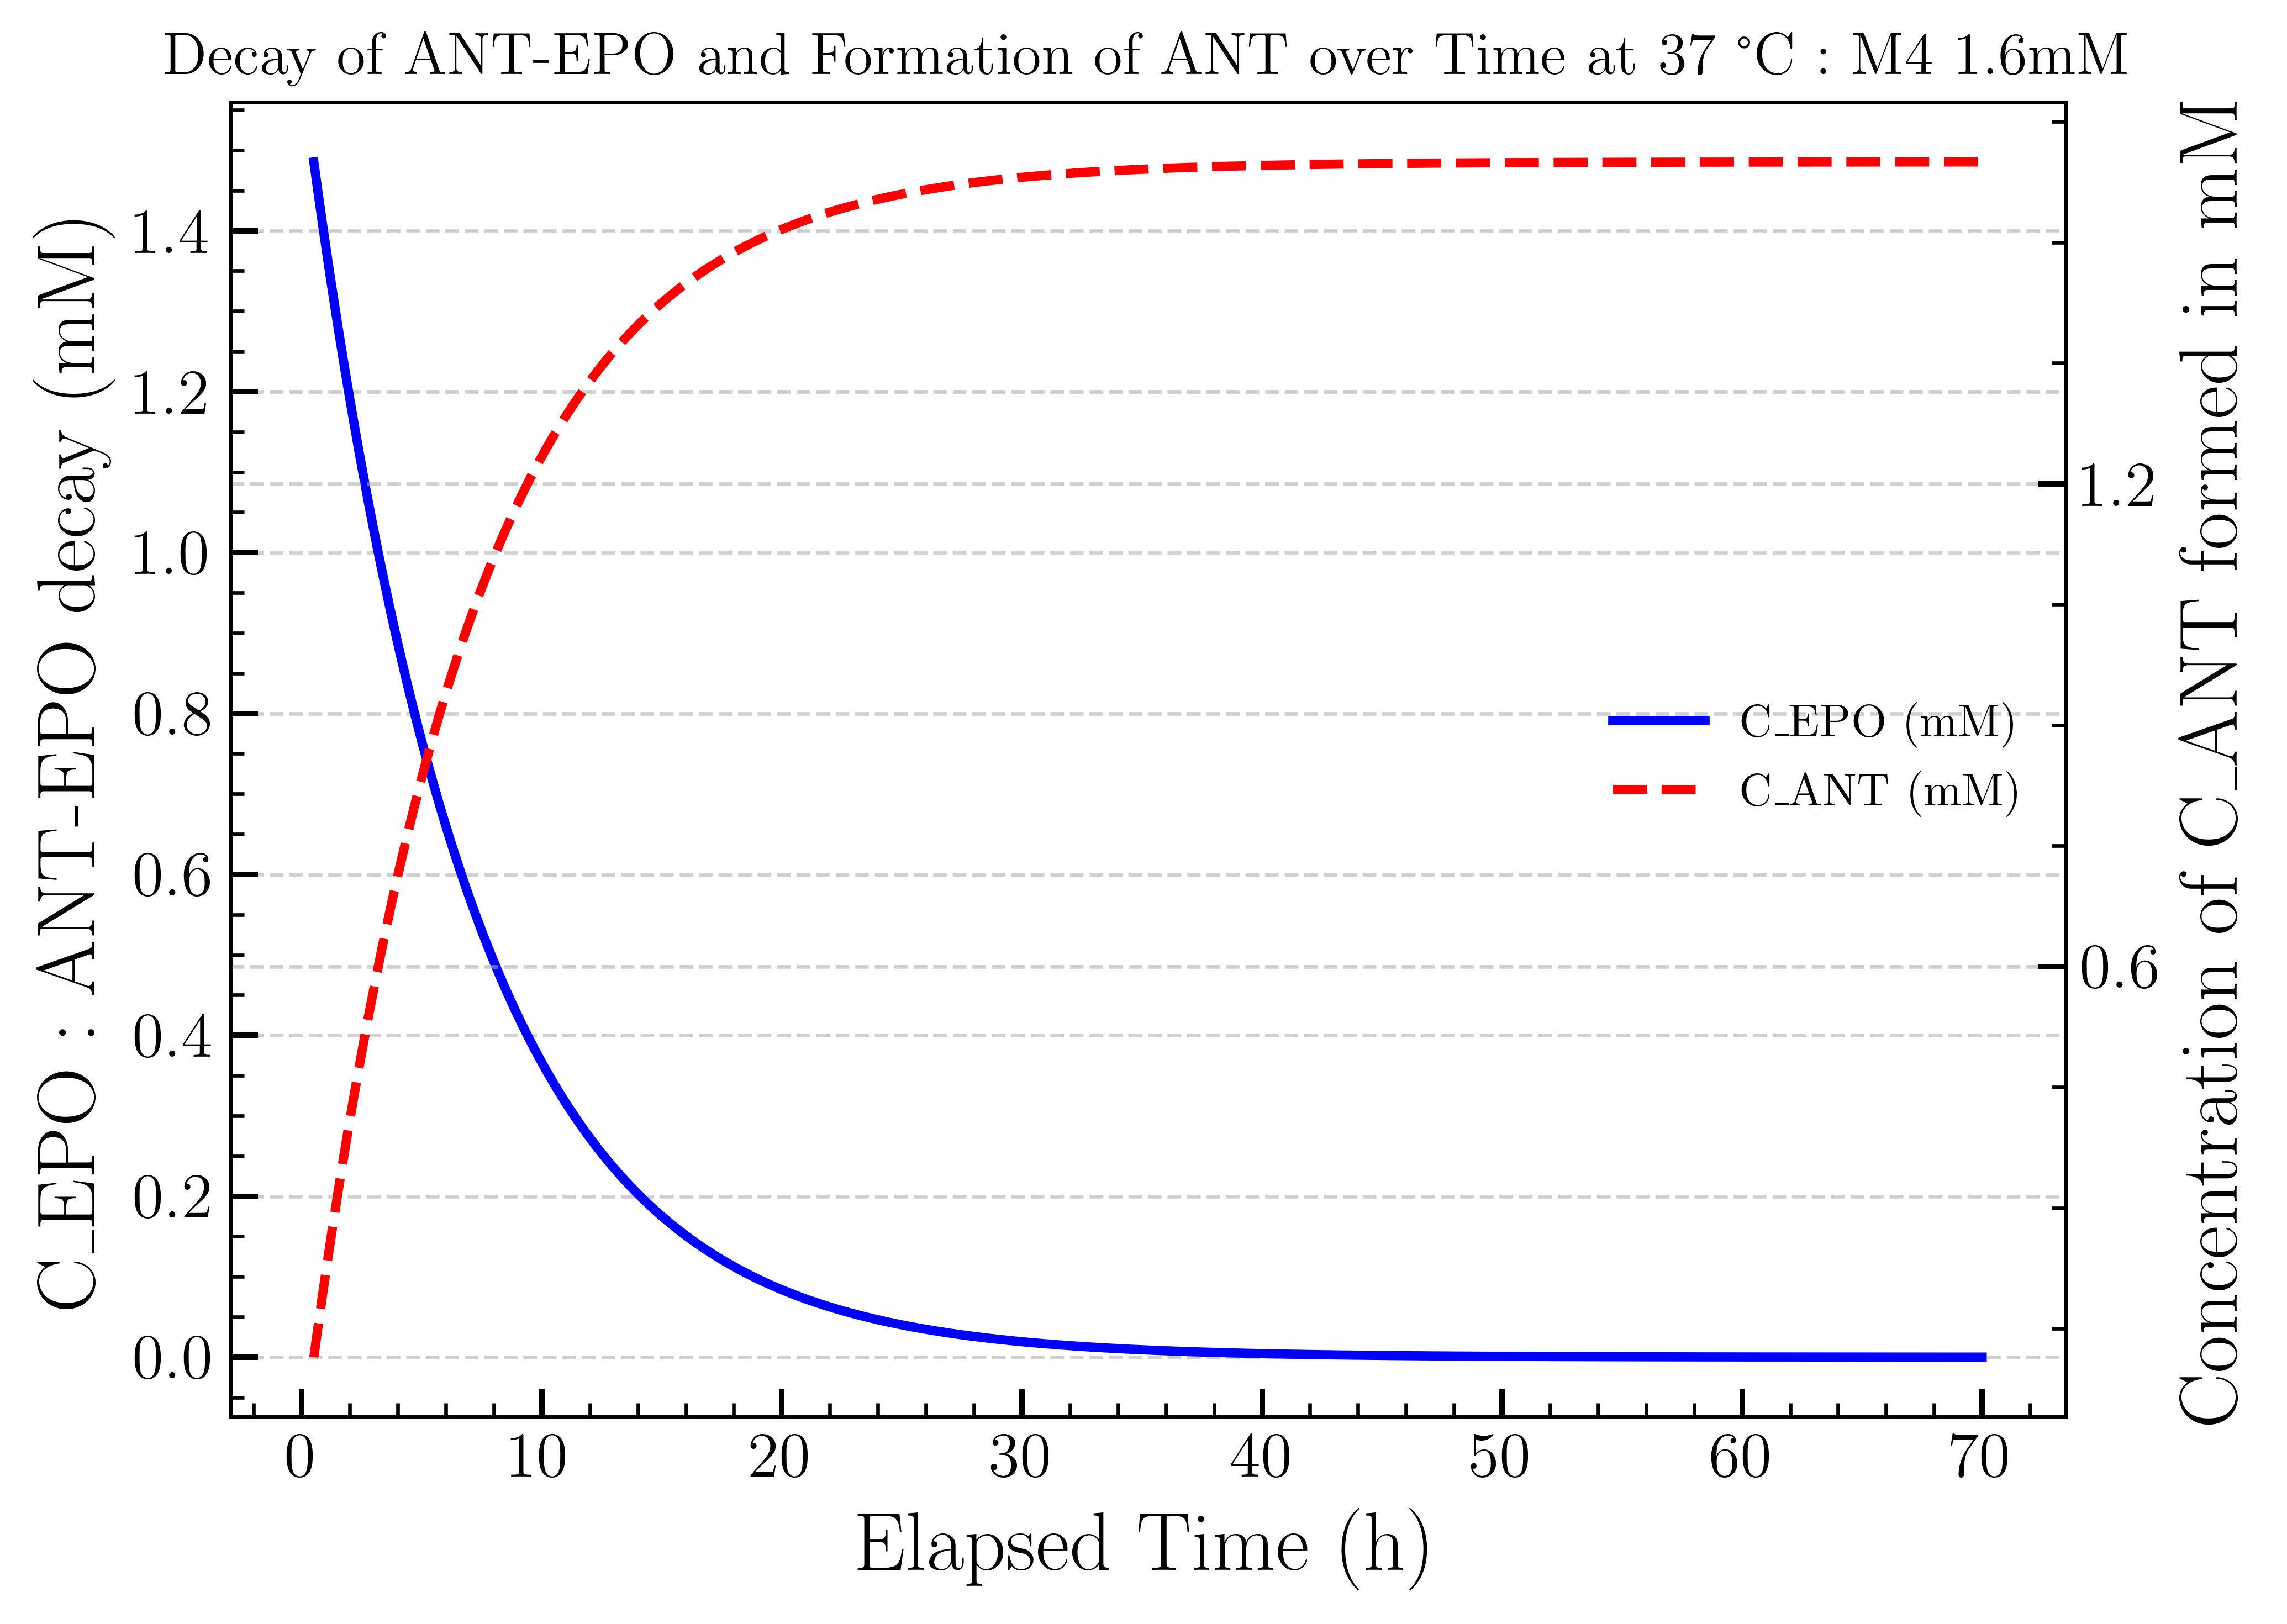

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_0 = 1.6        # initial ANT-EPO concentration (mM)
t_half = 4.7    # hours at 37 °C
fig, ax1 = plt.subplots(figsize=(7,5), dpi=600)

# Left axis: C_EPO
ax1.plot(out_dataframe["Elapsed time"], out_dataframe["N (t)"], 'b-', linewidth=2, label=r"C_EPO (mM)")
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel=r"C_EPO : ANT-EPO decay (mM)")
# ax1.tick_params(axis='y', labelcolor='b')

# Right axis: C_ANT
ax2 = ax1.twinx()
ax2.plot(out_dataframe["Elapsed time"], out_dataframe["C_ANT_mM"], 'r--', linewidth=2, label=r"C_ANT (mM)")
style_axes(ax2, xlabel="Elapsed Time (h)", ylabel="Concentration of C_ANT formed in mM", y_major=0.6)
# ax2.tick_params(axis='y', labelcolor='r')



ax1.set_title('Decay of ANT-EPO and Formation of ANT over Time at 37 °C : M4 1.6mM', fontsize=13)
# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, fontsize=10, loc="right")
plt.tight_layout()
plt.show()

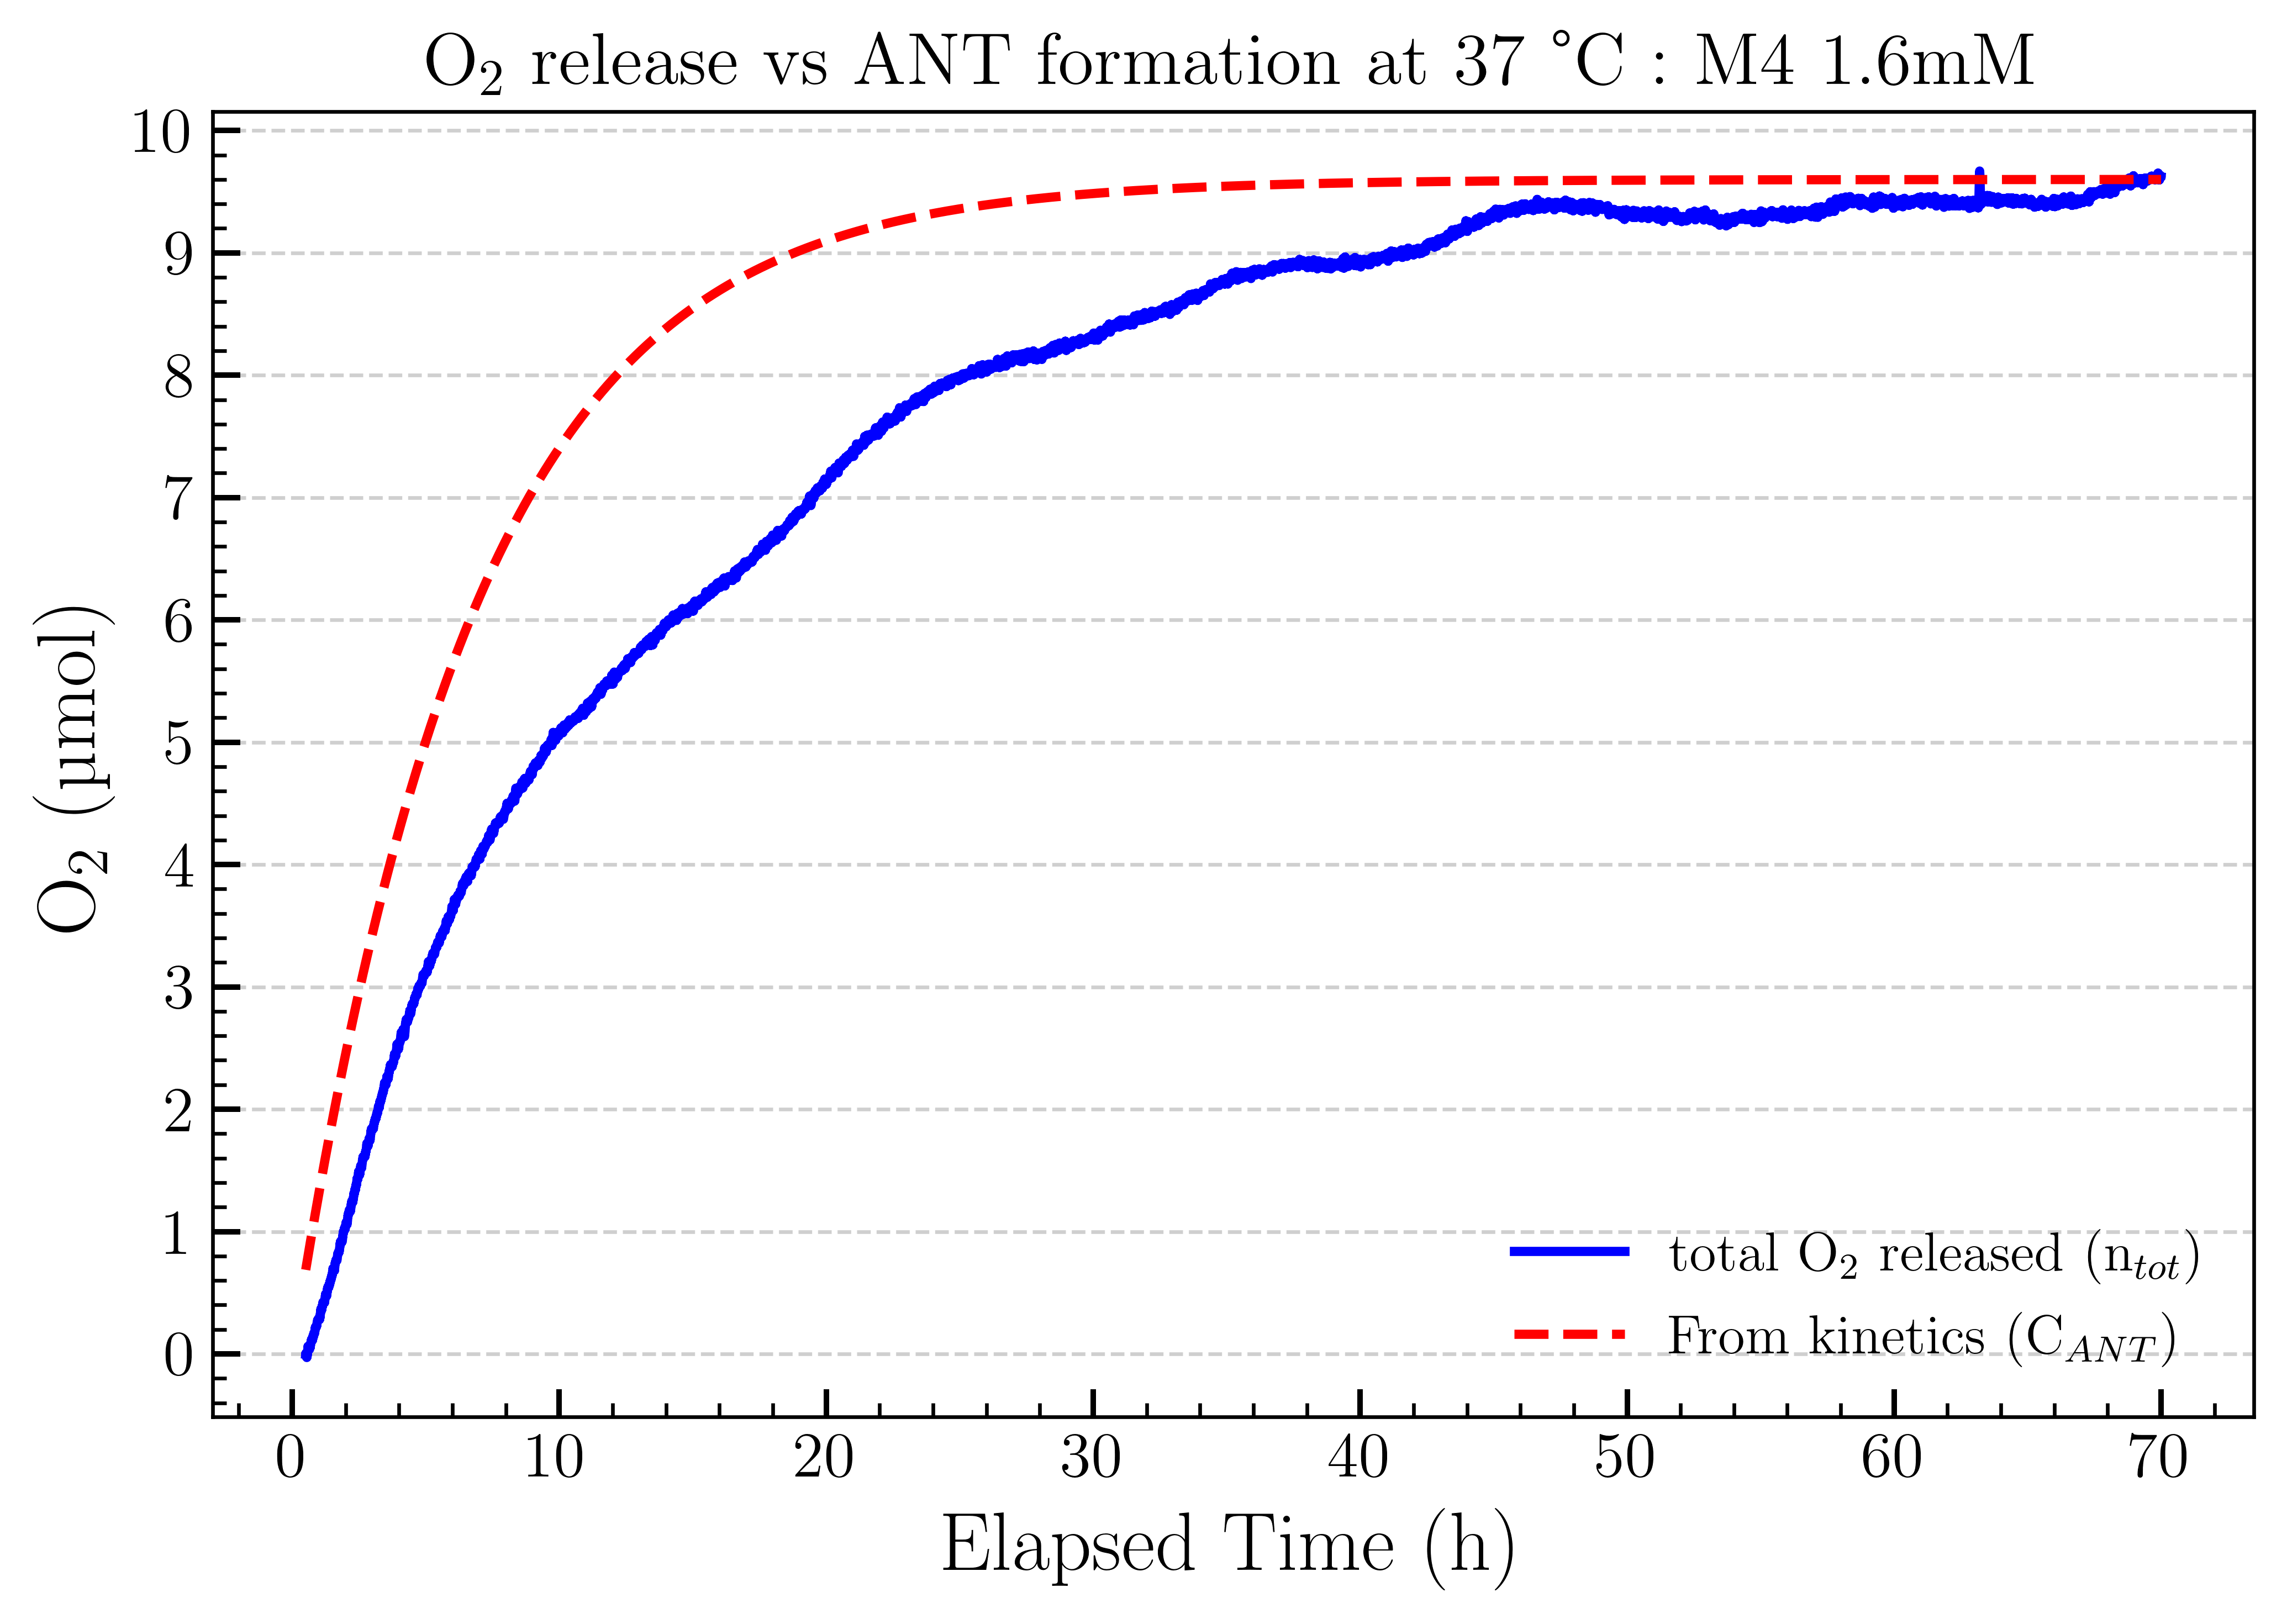

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
df_in = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M4-1.6 mM\37 C\code files\M4_1.6mM_37deg_pressure_o2_release.csv")
time_h = df_in["Time (h)"]
ntot_umol = df_in["ABP2 O2 Released (µmol)"]


# constants
R, Vsol, Vg = 0.082057, 0.006, 0.004
n_theory = 9.6  # µmol




df_out = pd.DataFrame({"Elapsed time (h)": time_h, "ntotal (µmol)": ntot_umol}).dropna()





# kinetics (ANT → O2 proxy)
n0_mM  = 1.6    # initial mM
t_half = 4.7      # hours at 37 °C
C_ANT_mM  = n0_mM * (1 - 0.5**(time_h / t_half))   #simply the complement of the first expression that showed the decomposition of ANT-EPO
C_ANT_umol = C_ANT_mM * Vsol * 1000

# plot in µmol 



fig, ax1 = plt.subplots(figsize=(7,5), dpi=600)
ax1.plot(time_h, df_out["ntotal (µmol)"], 'b-', lw=2, label=r"total O$_2$ released (n$_{tot}$)")
ax1.plot(time_h, C_ANT_umol, 'r--', lw=2, label=r"From kinetics (C$_{ANT}$)")
ax1.set_title('O$_2$ release vs ANT formation at 37 °C : M4 1.6mM', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="O$_2$ (µmol)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()